# Segmentation client non-supervisée — Pipeline ML

**Objectif** : découvrir des **profils comportementaux** parmi les clients `ACTIVE` à partir de leurs données d'usage et de crédit, **sans étiquette de churn** et **sans score métier pré-calculé**.

Le résultat est un segment (`cluster_id` + `cluster_name`) et un flag d'anomalie (`anomaly_flag`) exploitables par un système multi-agents en aval.

---

## Logique du pipeline

| Étape | Raison d'être | Sortie |
|---|---|---|
| **EDA** | Diagnostiquer ce qui rend les données difficiles (zero-inflation, skewness, collinéarité) **avant** de modéliser | Checklist de décisions pour la prépa |
| **Nettoyage** | Réparer les problèmes structurels (types, doublons, NaN) + winsoriser les outliers extrêmes | `df_clean` |
| **Feature engineering** | Créer de la **variance exploitable** là où les features brutes sont quasi-constantes (ratios, flags binaires, log) | ~15 features au lieu de 4 |
| **Périmètre ACTIVE** | Les STATE non-ACTIVE (DISCO/SUSPENDED/ON-HOLD) sont déjà segmentés par l'état administratif → aucune valeur ajoutée à les clusteriser | clients ACTIVE du dataset étudié |
| **Prépa modèle** | `PowerTransformer` (Yeo-Johnson) + scaler robuste pour redresser les distributions | matrice `X` |
| **Choix de K** | Croiser **4 métriques** (inertie, silhouette, DB, CH) + contrainte "aucun cluster < 0.5%" | K* |
| **Clustering** | Comparer **MiniBatchKMeans**, **GaussianMixture**, **BisectingKMeans** pour choisir ce qui matche la vraie structure | labels |
| **Interprétation** | Nommer chaque cluster automatiquement depuis ses **features les plus déviantes** (z-score vs population) | `cluster_name` |
| **Anomalies** | Isolation Forest sur le même pipeline de features | `anomaly_flag` |

---

## Principes de conception

1. **Segmentation comportementale non supervisée** — aucune étiquette, aucun score précalculé en entrée du clustering.
2. **Interprétabilité par construction** — chaque cluster est nommé via les features réelles qui le distinguent, pas via un score externe.
3. **Honnêteté sur les limites** — à chaque étape on mesure ce qui marche et ce qui ne marche pas (pas de silhouette trompeuse).

## 1. Imports et configuration

- `sklearn.preprocessing.PowerTransformer` (Yeo-Johnson) a été choisi car il accepte les valeurs nulles et positives, contrairement à Box-Cox qui exige des valeurs strictement positives. Il est adapté aux distributions asymétriques observées dans les variables financières.
- `MiniBatchKMeans` pour tenir à l'échelle une montée en charge si le volume augmente.
- `GaussianMixture` pour comparaison (clustering probabiliste).
- `BisectingKMeans` (hiérarchique descendant, plus stable que KMeans sur données déséquilibrées).
- `IsolationForest` pour la détection d'anomalies.

In [1]:
# Sécurisation de l'exécution locale Windows / VS Code.
# Ces variables limitent les conflits de threads BLAS/OpenMP avec scikit-learn.
import os

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

'1'

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PowerTransformer, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans, BisectingKMeans
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environnement prêt.")

Environnement prêt.


## 2. Chargement brut

On lit le CSV **tel quel** — pas de filtrage, pas de conversion, juste un constat de ce qu'on a entre les mains.

In [3]:
from pathlib import Path
import pandas as pd

# Chemins reproductibles : le notebook peut être lancé depuis la racine du projet
# ou depuis le dossier machine_learning/notebooks.
CURRENT_DIR = Path.cwd()
PROJECT_DIR = CURRENT_DIR
if PROJECT_DIR.name == "machine_learning":
    ML_DIR = PROJECT_DIR
elif (PROJECT_DIR / "machine_learning").exists():
    ML_DIR = PROJECT_DIR / "machine_learning"
else:
    # Fallback utile si le notebook est lancé depuis un sous-dossier.
    candidates = [p for p in [CURRENT_DIR, *CURRENT_DIR.parents] if (p / "machine_learning").exists()]
    if not candidates:
        raise FileNotFoundError("Impossible de localiser le dossier machine_learning. Lance le notebook depuis la racine du projet.")
    PROJECT_DIR = candidates[0]
    ML_DIR = PROJECT_DIR / "machine_learning"

DATA_PATH = Path(r'C:\\Users\\benab\\OneDrive\\Bureau\\PFE TT\\PLATEFORME TT\\backend\\runtime_data\\ml_imports\\10\\merged_dataset_inner.csv')
EXPORT_DIR = Path(r'C:\\Users\\benab\\OneDrive\\Bureau\\PFE TT\\PLATEFORME TT\\backend\\runtime_data\\ml_imports\\10')
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

df_raw = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Projet     : {PROJECT_DIR}")
print(f"ML_DIR     : {ML_DIR}")
print(f"Fichier lu : {DATA_PATH}")
print(f"Shape      : {df_raw.shape[0]:,} lignes x {df_raw.shape[1]} colonnes")

print("\nColonnes :")
for c in df_raw.columns:
    print(f"  - {c:30s} {df_raw[c].dtype}")

df_raw.head(3)

Projet     : C:\Users\benab\OneDrive\Bureau\PFE TT\PLATEFORME TT
ML_DIR     : C:\Users\benab\OneDrive\Bureau\PFE TT\PLATEFORME TT\machine_learning
Fichier lu : C:\Users\benab\OneDrive\Bureau\PFE TT\PLATEFORME TT\backend\runtime_data\ml_imports\10\merged_dataset_inner.csv
Shape      : 9,748 lignes x 14 colonnes

Colonnes :
  - MSISDN                         int64
  - STATE_IN                       object
  - SUBSCRIBER_TYPE_IN             object
  - RATE_PLAN                      object
  - ACCOUNT_ACTIVATED_DATE         object
  - AVG_CREDIT_AMOUNT              float64
  - AVG_CREDIT_FEE                 float64
  - AVG_REIMBURSED_AMOUNT          float64
  - AVG_FEE_REIMBURSED             float64
  - AVG_REIMBURSE_RATIO            float64
  - AVG_DAYS_SINCE_CREDIT          float64
  - TOTAL_OUTSTANDING_AMOUNT       float64
  - TOTAL_OUTSTANDING_FEE          float64
  - NB_SOS                         int64


,MSISDN,STATE_IN,SUBSCRIBER_TYPE_IN,RATE_PLAN,ACCOUNT_ACTIVATED_DATE,AVG_CREDIT_AMOUNT,AVG_CREDIT_FEE,AVG_REIMBURSED_AMOUNT,AVG_FEE_REIMBURSED,AVG_REIMBURSE_RATIO,AVG_DAYS_SINCE_CREDIT,TOTAL_OUTSTANDING_AMOUNT,TOTAL_OUTSTANDING_FEE,NB_SOS
0,21696330926,ACTIVE,PREPAID,PRE - Ola,2007-09-20,2.542,0.508,2.475,0.492,0.933,60.083,0.800,0.200,12
1,21699807992,ACTIVE,HYB,Corporate Optimum Plus,2025-11-04,3.000,0.600,1.200,0.240,0.400,14.800,9.000,1.800,5
2,21699128564,ACTIVE,HYB,Corporate Optimum Plus,2025-11-03,2.500,0.500,2.500,0.500,1.000,31.000,0.000,0.000,7


## 3. EDA — Diagnostic avant modélisation

**Principe** : on ne nettoie pas et on ne clusterise pas "à l'aveugle". Avant tout, on mesure ce qui va poser problème pour les algorithmes de clustering :

1. **Types & valeurs manquantes** — savoir ce qu'il faut convertir/imputer.
2. **Distributions** — détecter skewness et zero-inflation (deux ennemis du KMeans).
3. **Corrélations** — repérer la collinéarité (redondance qui biaise la distance).
4. **Variabilité par STATE** — voir quelles features portent réellement de l'info.
5. **Clusterisabilité** — estimer s'il existe vraiment des groupes dans les données, ou si on a un point massif et rien d'autre.

### 3.1 Types, manquants, doublons

In [4]:
diag = pd.DataFrame({
    "dtype":      df_raw.dtypes.astype(str),
    "n_missing":  df_raw.isna().sum(),
    "pct_missing": (df_raw.isna().sum() / len(df_raw) * 100).round(2),
    "n_unique":   df_raw.nunique(dropna=True),
})
print(f"Lignes totales   : {len(df_raw):,}")
print(f"Doublons MSISDN  : {df_raw['MSISDN'].duplicated().sum():,}")
print(f"Lignes distinctes: {df_raw.drop_duplicates().shape[0]:,}")
diag

Lignes totales   : 9,748
Doublons MSISDN  : 0
Lignes distinctes: 9,748


,dtype,n_missing,pct_missing,n_unique
MSISDN,int64,0,0.000,9748
STATE_IN,object,0,0.000,4
SUBSCRIBER_TYPE_IN,object,28,0.290,2
RATE_PLAN,object,28,0.290,68
ACCOUNT_ACTIVATED_DATE,object,28,0.290,4120
AVG_CREDIT_AMOUNT,float64,0,0.000,3769
AVG_CREDIT_FEE,float64,0,0.000,2998
AVG_REIMBURSED_AMOUNT,float64,0,0.000,4046
AVG_FEE_REIMBURSED,float64,0,0.000,2772
AVG_REIMBURSE_RATIO,float64,0,0.000,2536


### 3.2 Distribution de la cible descriptive `STATE_IN`

`STATE_IN` n'est pas une cible supervisée, mais c'est la **variable administrative de référence** — elle nous servira plus tard à interpréter les clusters et à circonscrire le périmètre de clustering.

                      count    pct
STATE_IN                          
ACTIVE                 9208 94.460
SUSPENDED               497  5.100
Disconnected Network     28  0.290
ON-HOLD                  15  0.150


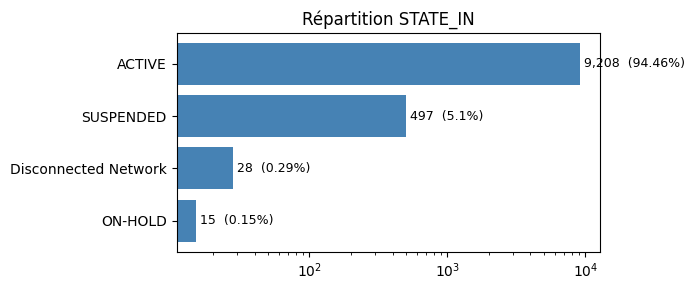

In [5]:
state_counts = df_raw["STATE_IN"].value_counts(dropna=False)
state_pct = (state_counts / len(df_raw) * 100).round(2)
state_summary = pd.DataFrame({"count": state_counts, "pct": state_pct})
print(state_summary)

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(state_counts.index[::-1], state_counts.values[::-1], color="steelblue")
for i, v in enumerate(state_counts.values[::-1]):
    ax.text(v, i, f" {v:,}  ({state_pct.iloc[::-1].iloc[i]}%)", va="center", fontsize=9)
ax.set_title("Répartition STATE_IN")
ax.set_xscale("log")
plt.tight_layout(); plt.show()

### 3.3 Statistiques et skewness des features numériques

Pour chaque feature on calcule :

- **skewness** : si `|skew| > 1` → distribution fortement asymétrique (mauvaise pour KMeans tel quel)
- **kurtosis** : outliers extrêmes si `> 3`
- **% de zéros** : signal de "zero-inflation" (point masse à 0 qui peut figer un cluster entier)

In [6]:
NUMERIC_RAW = [
    "AVG_CREDIT_AMOUNT", "AVG_CREDIT_FEE",
    "AVG_REIMBURSED_AMOUNT", "AVG_FEE_REIMBURSED",
    "AVG_REIMBURSE_RATIO", "AVG_DAYS_SINCE_CREDIT",
    "TOTAL_OUTSTANDING_AMOUNT", "TOTAL_OUTSTANDING_FEE",
    "NB_SOS",
]

_df_num = df_raw[NUMERIC_RAW].apply(pd.to_numeric, errors="coerce")

stats = pd.DataFrame({
    "mean":    _df_num.mean(),
    "median":  _df_num.median(),
    "std":     _df_num.std(),
    "min":     _df_num.min(),
    "p95":     _df_num.quantile(0.95),
    "max":     _df_num.max(),
    "skew":    _df_num.skew(),
    "kurt":    _df_num.kurt(),
    "pct_zero": ((_df_num == 0).sum() / len(_df_num) * 100),
}).round(2)
stats

,mean,median,std,min,p95,max,skew,kurt,pct_zero
AVG_CREDIT_AMOUNT,2.160,1.410,2.820,0.200,5.000,55.000,6.170,58.280,0.000
AVG_CREDIT_FEE,0.430,0.280,0.560,0.040,1.000,11.000,6.190,58.470,0.000
AVG_REIMBURSED_AMOUNT,1.720,1.000,2.410,0.000,4.860,45.000,6.390,62.160,4.880
AVG_FEE_REIMBURSED,0.320,0.200,0.430,0.000,0.900,7.670,6.180,61.930,6.650
AVG_REIMBURSE_RATIO,0.780,0.860,0.260,0.000,1.000,1.000,-1.590,2.140,4.880
AVG_DAYS_SINCE_CREDIT,46.700,45.840,17.140,1.000,79.000,90.000,0.240,-0.060,0.000
TOTAL_OUTSTANDING_AMOUNT,5.100,1.750,7.930,0.000,24.060,55.000,2.390,6.540,29.540
TOTAL_OUTSTANDING_FEE,1.200,0.400,1.800,0.000,5.500,18.600,2.420,7.430,27.830
NB_SOS,17.200,8.000,27.960,1.000,65.000,450.000,4.820,38.350,0.000


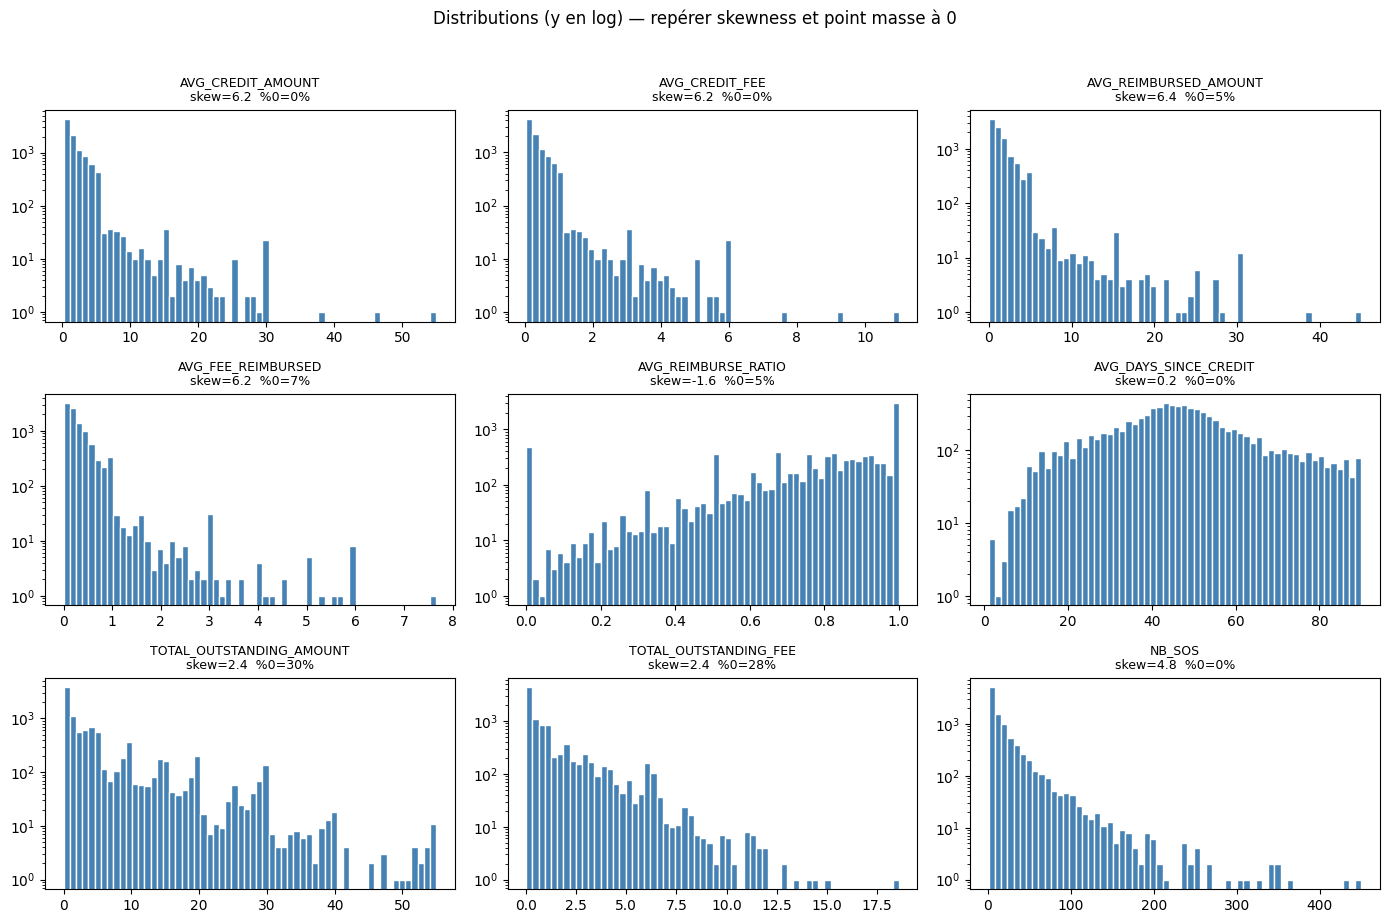

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
for ax, col in zip(axes.ravel(), NUMERIC_RAW):
    vals = _df_num[col].dropna()
    ax.hist(vals, bins=60, color="steelblue", edgecolor="white")
    ax.set_yscale("log")
    ax.set_title(f"{col}\nskew={vals.skew():.1f}  %0={(vals == 0).mean()*100:.0f}%", fontsize=9)
plt.suptitle("Distributions (y en log) — repérer skewness et point masse à 0", y=1.02)
plt.tight_layout(); plt.show()

### 3.4 Corrélations

On cherche les paires de features **redondantes** (corrélation > 0.9). Elles biaisent la distance euclidienne de KMeans : 2 features colinéaires comptent "2 fois" dans la distance.

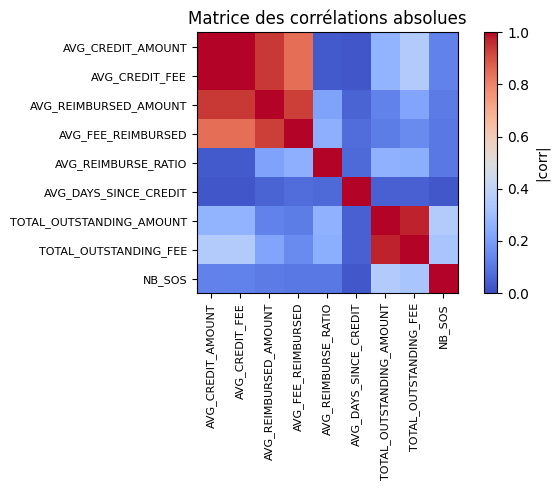

Paires fortement corrélées (|corr| > 0.9) :
  AVG_CREDIT_AMOUNT              <-> AVG_CREDIT_FEE                  = 1.000
  TOTAL_OUTSTANDING_AMOUNT       <-> TOTAL_OUTSTANDING_FEE           = 0.970
  AVG_CREDIT_AMOUNT              <-> AVG_REIMBURSED_AMOUNT           = 0.944
  AVG_CREDIT_FEE                 <-> AVG_REIMBURSED_AMOUNT           = 0.944
  AVG_REIMBURSED_AMOUNT          <-> AVG_FEE_REIMBURSED              = 0.932


In [8]:
corr = _df_num.corr().abs()

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=0, vmax=1)
ax.set_xticks(range(len(NUMERIC_RAW))); ax.set_xticklabels(NUMERIC_RAW, rotation=90, fontsize=8)
ax.set_yticks(range(len(NUMERIC_RAW))); ax.set_yticklabels(NUMERIC_RAW, fontsize=8)
plt.colorbar(im, ax=ax, label="|corr|")
ax.set_title("Matrice des corrélations absolues")
plt.tight_layout(); plt.show()

pairs = [(a, b, corr.loc[a, b]) for i, a in enumerate(NUMERIC_RAW) for b in NUMERIC_RAW[i+1:] if corr.loc[a, b] > 0.9]
print("Paires fortement corrélées (|corr| > 0.9) :")
for a, b, v in sorted(pairs, key=lambda x: -x[2]):
    print(f"  {a:30s} <-> {b:30s}  = {v:.3f}")

### 3.5 Variabilité par STATE

Question clé : **les features numériques portent-elles de l'info au-delà de STATE ?**  
Si la moyenne d'une feature est quasi identique entre ACTIVE et SUSPENDED, elle n'aide pas à sub-segmenter les ACTIVE.

In [9]:
_df_eda = df_raw.copy()
_df_eda[NUMERIC_RAW] = _df_num

by_state = _df_eda.groupby("STATE_IN")[NUMERIC_RAW].median().T
by_state["var_inter_state"] = by_state.std(axis=1) / (by_state.mean(axis=1).abs() + 1e-9)
by_state.sort_values("var_inter_state", ascending=False)

STATE_IN,ACTIVE,Disconnected Network,ON-HOLD,SUSPENDED,var_inter_state
AVG_FEE_REIMBURSED,0.200,0.246,0.000,0.056,0.929
AVG_REIMBURSED_AMOUNT,1.100,1.225,0.000,0.340,0.888
NB_SOS,8.000,3.500,1.000,3.000,0.762
AVG_REIMBURSE_RATIO,0.867,0.833,0.000,0.667,0.683
AVG_CREDIT_AMOUNT,1.500,2.447,0.900,0.650,0.581
AVG_CREDIT_FEE,0.300,0.490,0.200,0.131,0.557
TOTAL_OUTSTANDING_AMOUNT,2.000,2.325,0.900,0.750,0.526
TOTAL_OUTSTANDING_FEE,0.500,0.525,0.200,0.200,0.507
AVG_DAYS_SINCE_CREDIT,45.210,71.986,89.000,63.000,0.271


### 3.6 Diagnostic de clusterisabilité

**Question critique** : combien de clients sont "inertes" — c.-à-d. tous leurs signaux comportementaux à zéro ?  
Si 90% des clients ont `NB_SOS=0`, `OUTSTANDING=0`, ratio proche de la médiane → **ils occupent tous le même point** dans l'espace des features, et aucun algorithme ne peut les clusteriser.

C'est la **cause racine** des méga-clusters qu'on observait avant.

In [10]:
SIGNAL_FEATURES = ["NB_SOS", "TOTAL_OUTSTANDING_AMOUNT", "TOTAL_OUTSTANDING_FEE"]

inert_mask = (_df_num[SIGNAL_FEATURES] == 0).all(axis=1)
n_inert = int(inert_mask.sum())
n_total = len(_df_num)

print(f"Clients totalement inertes (NB_SOS=0 ET OUTSTANDING=0 ET OUTSTANDING_FEE=0) :")
print(f"  {n_inert:,} / {n_total:,}  ({n_inert/n_total:.1%})")
print()

for col in SIGNAL_FEATURES + ["AVG_DAYS_SINCE_CREDIT"]:
    pct_zero = (_df_num[col] == 0).mean() * 100
    pct_modal = (_df_num[col] == _df_num[col].mode().iloc[0]).mean() * 100
    print(f"  {col:30s} | % = 0 : {pct_zero:5.1f}% | % à la valeur modale : {pct_modal:5.1f}%")

Clients totalement inertes (NB_SOS=0 ET OUTSTANDING=0 ET OUTSTANDING_FEE=0) :
  0 / 9,748  (0.0%)

  NB_SOS                         | % = 0 :   0.0% | % à la valeur modale :  16.0%
  TOTAL_OUTSTANDING_AMOUNT       | % = 0 :  29.5% | % à la valeur modale :  29.5%
  TOTAL_OUTSTANDING_FEE          | % = 0 :  27.8% | % à la valeur modale :  27.8%
  AVG_DAYS_SINCE_CREDIT          | % = 0 :   0.0% | % à la valeur modale :   0.6%


### 3.7 Synthèse EDA — Décisions de prépa

De ce diagnostic, on tire **les règles de conception** du pipeline :

| Problème observé | Conséquence si ignoré | Décision |
|---|---|---|
| Skewness élevée sur OUTSTANDING, NB_SOS | Les outliers dominent la distance euclidienne | **Winsoriser au p99** puis **Yeo-Johnson** |
| Point masse à 0 très dense | KMeans colle tous les 0 dans un cluster écrasant | **Feature engineering** : créer des flags binaires (`has_debt`, `uses_sos`) pour séparer le point 0 du reste |
| Features OUTSTANDING_AMOUNT ≈ OUTSTANDING_FEE (colinéaires) | Redondance → distance biaisée | **Garder seulement OUTSTANDING_AMOUNT** et construire un `fee_ratio` |
| AVG_REIMBURSED_AMOUNT redondant avec RATIO | idem | **Garder RATIO**, dropper les absolus |
| Clients non-ACTIVE (~5% du total) | Leur STATE suffit à les segmenter | **Clusteriser uniquement les ACTIVE** |
| Inertes (tout à zéro) | Impossibles à distinguer par clustering | Flag `is_dormant_like` pour les **exclure de la distance** et les suivre à part |

## 4. Nettoyage structurel + winsorisation

**Étape en deux temps** :

1. **Nettoyage structurel** (corrections factuelles) : typage numérique, normalisation de `STATE_IN`, parsing des dates, imputation médiane des manquants (<1%), déduplication par `MSISDN`.
2. **Winsorisation** (traitement statistique) : plafonner les valeurs au **p99** des features long-tail. Pourquoi pas drop ? On veut **garder les clients extrêmes** (ils sont peut-être les plus intéressants pour l'anomaly detection), mais empêcher qu'ils écrasent la distance euclidienne du clustering.

In [11]:
STATE_MAPPING = {
    "ACTIVE": "ACTIVE",
    "SUSPENDED": "SUSPENDED",
    "ON-HOLD": "ON-HOLD",
    "ON HOLD": "ON-HOLD",
    "DISCONNECTED": "DISCONNECTED",
    "DISCONNECTED NETWORK": "DISCONNECTED",
}

df = df_raw.copy()

df["STATE"] = (
    df["STATE_IN"]
    .astype(str)
    .str.strip()
    .str.upper()
    .map(STATE_MAPPING)
    .fillna("OTHER")
)


for col in NUMERIC_RAW:
    df[col] = pd.to_numeric(df[col], errors="coerce")


if "ACCOUNT_ACTIVATED_DATE" in df.columns:
    df["ACTIVATION_DATE"] = pd.to_datetime(
        df["ACCOUNT_ACTIVATED_DATE"],
        errors="coerce"
    )


if "LAST_CREDIT_DATE" in df.columns:
    df["LAST_CREDIT_DATE"] = pd.to_datetime(
        df["LAST_CREDIT_DATE"],
        errors="coerce"
    )

miss_before = df[NUMERIC_RAW].isna().sum().sum()
for col in NUMERIC_RAW:
    df[col] = df[col].fillna(df[col].median())

before = len(df)
df = df.drop_duplicates(subset="MSISDN", keep="last").reset_index(drop=True)
dups_removed = before - len(df)

print(f"Manquants imputés (médiane) : {miss_before:,}")
print(f"Doublons MSISDN supprimés   : {dups_removed:,}")
print(f"Shape après nettoyage       : {df.shape}")
print(f"\nRépartition STATE :")
print(df["STATE"].value_counts())

Manquants imputés (médiane) : 0
Doublons MSISDN supprimés   : 0
Shape après nettoyage       : (9748, 16)

Répartition STATE :
STATE
ACTIVE          9208
SUSPENDED        497
DISCONNECTED      28
ON-HOLD           15
Name: count, dtype: int64


### 4.1 Winsorisation au 99e percentile

On applique le plafond **uniquement aux features long-tail** (celles avec `skew > 3` ou `kurt > 10` d'après la section 3.3). Les ratios (`AVG_REIMBURSE_RATIO`) ne sont pas winsorisés : bornés par nature entre 0 et ~1.

In [12]:
WINSORIZE_COLS = [
    "AVG_CREDIT_AMOUNT", "AVG_CREDIT_FEE",
    "AVG_REIMBURSED_AMOUNT", "AVG_FEE_REIMBURSED",
    "AVG_DAYS_SINCE_CREDIT",
    "TOTAL_OUTSTANDING_AMOUNT", "TOTAL_OUTSTANDING_FEE",
    "NB_SOS",
]

winsor_log = []
for col in WINSORIZE_COLS:
    cap = df[col].quantile(0.99)
    n_capped = int((df[col] > cap).sum())
    df[col] = df[col].clip(upper=cap)
    winsor_log.append({"feature": col, "p99_cap": round(cap, 2), "n_capped": n_capped})

pd.DataFrame(winsor_log)

,feature,p99_cap,n_capped
0,AVG_CREDIT_AMOUNT,15.000,81
1,AVG_CREDIT_FEE,3.000,81
2,AVG_REIMBURSED_AMOUNT,12.370,98
3,AVG_FEE_REIMBURSED,2.010,98
4,AVG_DAYS_SINCE_CREDIT,88.000,82
5,TOTAL_OUTSTANDING_AMOUNT,33.580,98
6,TOTAL_OUTSTANDING_FEE,7.900,96
7,NB_SOS,134.000,96


## 5. Feature engineering — créer la variance qui manque

**Constat de l'EDA** : les features brutes sont soit **corrélées**, soit **zero-inflated**. On ne peut pas espérer du clustering sur 4 dimensions où 3 sont redondantes.

**Stratégie** — on construit 3 familles de features :

1. **Ratios** → transforment une paire d'absolus en une seule feature métier pertinente (intensité, coût relatif).
2. **Flags binaires** → isolent le comportement "actif sur ce signal" du "inactif". Un client avec `has_debt=1` est **qualitativement** différent d'un client à 0, même si leurs `OUTSTANDING` bruts sont proches.
3. **Tenure & fréquence** → créent une dimension temporelle (ancienneté, intensité d'usage).

Ces features sont conçues pour que **2 clients aux comportements différents soient à des distances différentes** dans l'espace final — ce qui ne l'était pas avec les features brutes.

In [13]:
EPS = 1e-6

df["reimburse_ratio"]  = df["AVG_REIMBURSE_RATIO"].clip(lower=0, upper=1.5)
df["fee_to_credit"]    = df["AVG_CREDIT_FEE"] / (df["AVG_CREDIT_AMOUNT"] + EPS)
df["debt_to_credit"]   = df["TOTAL_OUTSTANDING_AMOUNT"] / (df["AVG_CREDIT_AMOUNT"] + EPS)
df["fee_burden"]       = df["TOTAL_OUTSTANDING_FEE"]    / (df["TOTAL_OUTSTANDING_AMOUNT"] + EPS)

for c in ["fee_to_credit", "debt_to_credit", "fee_burden"]:
    df[c] = df[c].clip(upper=df[c].quantile(0.99))

df["has_debt"]       = (df["TOTAL_OUTSTANDING_AMOUNT"] > 0).astype(int)
df["uses_sos"]       = (df["NB_SOS"] > 0).astype(int)
df["never_repaid"]   = (df["AVG_REIMBURSE_RATIO"] < 0.05).astype(int)
df["full_repayer"]   = (df["AVG_REIMBURSE_RATIO"] >= 0.95).astype(int)

if "ACTIVATION_DATE" in df.columns:
    ref = df["ACTIVATION_DATE"].max()
    df["tenure_days"] = (ref - df["ACTIVATION_DATE"]).dt.days.fillna(0).clip(lower=0)
else:
    df["tenure_days"] = 0

df["credit_intensity"] = df["NB_SOS"] / (df["tenure_days"] / 30 + 1)
df["credit_intensity"] = df["credit_intensity"].clip(upper=df["credit_intensity"].quantile(0.99))

df["is_dormant_like"] = (
    (df["NB_SOS"] == 0) &
    (df["TOTAL_OUTSTANDING_AMOUNT"] == 0) &
    (df["AVG_DAYS_SINCE_CREDIT"] > df["AVG_DAYS_SINCE_CREDIT"].quantile(0.80))
).astype(int)

NEW_FEATURES = [
    "reimburse_ratio", "fee_to_credit", "debt_to_credit", "fee_burden",
    "has_debt", "uses_sos", "never_repaid", "full_repayer",
    "tenure_days", "credit_intensity", "is_dormant_like",
]
df[NEW_FEATURES].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
reimburse_ratio,9748.000,0.783,0.257,0.000,0.670,0.861,1.000,1.000
fee_to_credit,9748.000,0.202,0.005,0.200,0.200,0.200,0.201,0.222
debt_to_credit,9748.000,2.840,3.999,0.000,0.000,1.419,3.736,21.973
fee_burden,9748.000,2791.254,23000.487,0.000,0.000,0.200,0.235,200000.000
has_debt,9748.000,0.705,0.456,0.000,0.000,1.000,1.000,1.000
uses_sos,9748.000,1.000,0.000,1.000,1.000,1.000,1.000,1.000
never_repaid,9748.000,0.049,0.216,0.000,0.000,0.000,0.000,1.000
full_repayer,9748.000,0.341,0.474,0.000,0.000,0.000,1.000,1.000
tenure_days,9748.000,2087.378,2214.979,0.000,458.000,1257.500,2848.250,9237.000
credit_intensity,9748.000,0.633,1.226,0.003,0.059,0.189,0.586,7.483


### 5.1 Validation : répartition des flags

On vérifie que les flags ne sont **ni tous à 0 ni tous à 1** (sinon ils n'apportent aucune info).

In [14]:
FLAGS = ["has_debt", "uses_sos", "never_repaid", "full_repayer", "is_dormant_like"]
flag_summary = pd.DataFrame({
    "% clients = 1 (global)": (df[FLAGS].mean() * 100).round(1),
    "% clients = 1 (ACTIVE)": (df.loc[df.STATE == "ACTIVE", FLAGS].mean() * 100).round(1),
})
flag_summary

,% clients = 1 (global),% clients = 1 (ACTIVE)
has_debt,70.500,70.100
uses_sos,100.000,100.000
never_repaid,4.900,3.600
full_repayer,34.100,34.600
is_dormant_like,0.000,0.000


## 6. Périmètre ACTIVE + matrice `X` de clustering

### Pourquoi restreindre aux ACTIVE ?

- **SUSPENDED / ON-HOLD / DISCONNECTED** sont déjà **segmentés** par leur état administratif — c'est une catégorisation imposée, pas à découvrir.
- Les inclure force l'algorithme à "retrouver" STATE comme axe principal → on perd la finesse sur les ACTIVE, qui sont **95% du parc** et **les seuls exploitables** par les agents métier (relance, cross-sell, rétention).

**Architecture finale** qui en découle :

```
Tout le parc
├── STATE ≠ ACTIVE → segment = STATE (déterministe, pas de ML)
└── STATE = ACTIVE  → clustering ML → cluster_name
```

### Sélection des features pour `X`

On **exclut** :
- Les features brutes redondantes (`AVG_REIMBURSED_AMOUNT`, `AVG_FEE_REIMBURSED`) — remplacées par les ratios.
- `TOTAL_OUTSTANDING_FEE` — fortement corrélée à `TOTAL_OUTSTANDING_AMOUNT`.
- `is_dormant_like` — servira en post-hoc (étiquetage), pas en distance.

In [15]:
df_active = df[df["STATE"] == "ACTIVE"].copy().reset_index(drop=True)
print(f"Clients ACTIVE : {len(df_active):,}  ({len(df_active)/len(df):.1%} du parc)")

CLUSTER_FEATURES = [
    "AVG_CREDIT_AMOUNT",
    "reimburse_ratio",
    "AVG_DAYS_SINCE_CREDIT",
    "TOTAL_OUTSTANDING_AMOUNT",
    "NB_SOS",
    "fee_to_credit",
    "debt_to_credit",
    "fee_burden",
    "credit_intensity",
    "tenure_days",
    "has_debt",
    "uses_sos",
    "never_repaid",
    "full_repayer",
]

print(f"\nFeatures retenues pour X ({len(CLUSTER_FEATURES)}) :")
for f in CLUSTER_FEATURES:
    print(f"  - {f}")

X_raw = df_active[CLUSTER_FEATURES].to_numpy(dtype=float)
print(f"\nShape X : {X_raw.shape}")

Clients ACTIVE : 9,208  (94.5% du parc)

Features retenues pour X (14) :
  - AVG_CREDIT_AMOUNT
  - reimburse_ratio
  - AVG_DAYS_SINCE_CREDIT
  - TOTAL_OUTSTANDING_AMOUNT
  - NB_SOS
  - fee_to_credit
  - debt_to_credit
  - fee_burden
  - credit_intensity
  - tenure_days
  - has_debt
  - uses_sos
  - never_repaid
  - full_repayer

Shape X : (9208, 14)


### 6.1 Transformation finale : Yeo-Johnson puis RobustScaler

**Pourquoi Yeo-Johnson** ?

- Il accepte les **valeurs nulles et négatives** (contrairement à `log1p` qui échoue sur négatifs).
- Il **apprend** le paramètre de puissance optimal par feature pour se rapprocher d'une gaussienne.
- Il est **monotone** → préserve l'ordre des clients.

Après Yeo-Johnson, `RobustScaler` centre sur la médiane et normalise par l'IQR : insensible aux résidus d'outliers.

**Important** : on `fit` sur un **échantillon de 200k** pour la vitesse, puis on `transform` tout le dataset.

Features à variance nulle retirées : ['fee_to_credit', 'uses_sos']


X shape : (9208, 12)
Features actives (12): ['AVG_CREDIT_AMOUNT', 'reimburse_ratio', 'AVG_DAYS_SINCE_CREDIT', 'TOTAL_OUTSTANDING_AMOUNT', 'NB_SOS', 'debt_to_credit', 'fee_burden', 'credit_intensity', 'tenure_days', 'has_debt', 'never_repaid', 'full_repayer']
std     : [0.62  0.517 0.863 0.504 0.645 0.485 0.624 0.586 0.645 0.458 0.005 0.476]


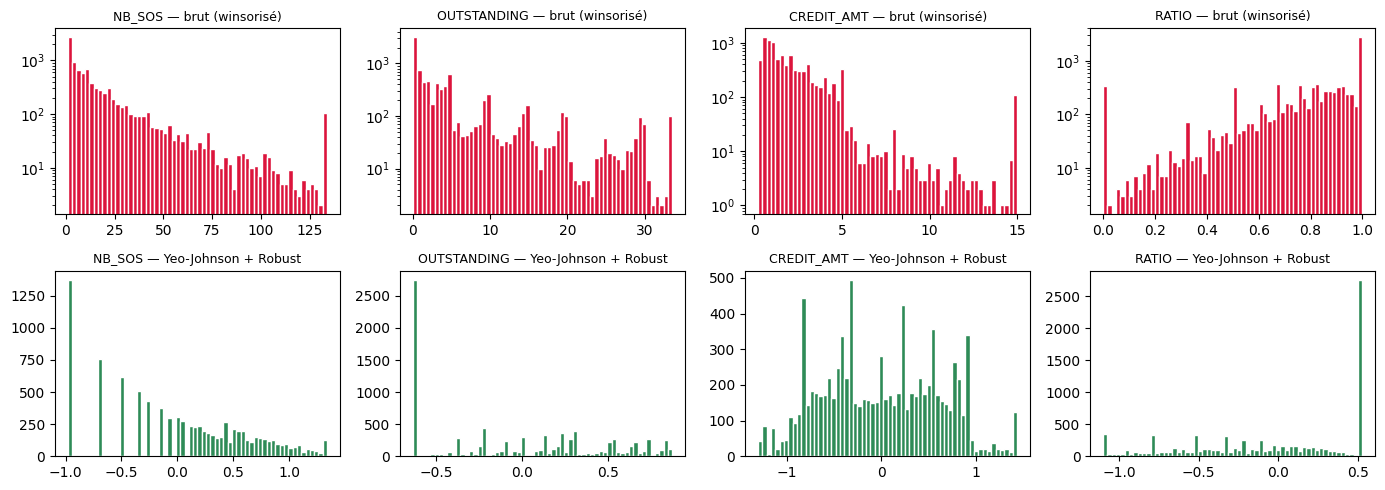

In [16]:
FIT_SAMPLE = 200_000
rng = np.random.default_rng(RANDOM_STATE)
fit_idx = rng.choice(len(X_raw), size=min(FIT_SAMPLE, len(X_raw)), replace=False)

yj = PowerTransformer(method="yeo-johnson", standardize=False).fit(X_raw[fit_idx])
X_yj = yj.transform(X_raw)

rs = RobustScaler().fit(X_yj[fit_idx])
X = rs.transform(X_yj)

# Filtrage automatique des features à variance nulle dans cet échantillon
# (ex: NB_SOS partout à 0 → uses_sos est constant → inutile et nuisible en clustering).
std_per_feature = X.std(axis=0)
keep_mask = std_per_feature > 1e-4
dropped = [CLUSTER_FEATURES[i] for i, keep in enumerate(keep_mask) if not keep]
if dropped:
    print(f"Features à variance nulle retirées : {dropped}")
    CLUSTER_FEATURES = [f for i, f in enumerate(CLUSTER_FEATURES) if keep_mask[i]]
    X_raw = X_raw[:, keep_mask]
    X = X[:, keep_mask]

print(f"X shape : {X.shape}")
print(f"Features actives ({len(CLUSTER_FEATURES)}): {CLUSTER_FEATURES}")
print(f"std     : {X.std(axis=0).round(3)}")

fig, axes = plt.subplots(2, 4, figsize=(14, 5))
n_show = min(30_000, len(X))
idx_show = rng.choice(len(X), size=n_show, replace=False)
cols_show = [CLUSTER_FEATURES.index(c) for c in ["NB_SOS", "TOTAL_OUTSTANDING_AMOUNT",
              "AVG_CREDIT_AMOUNT", "reimburse_ratio"]]
for i, (col_idx, col_name) in enumerate(zip(cols_show, ["NB_SOS", "OUTSTANDING", "CREDIT_AMT", "RATIO"])):
    axes[0, i].hist(X_raw[idx_show, col_idx], bins=60, color="crimson", edgecolor="white")
    axes[0, i].set_title(f"{col_name} — brut (winsorisé)", fontsize=9)
    axes[0, i].set_yscale("log")
    axes[1, i].hist(X[idx_show, col_idx], bins=60, color="seagreen", edgecolor="white")
    axes[1, i].set_title(f"{col_name} — Yeo-Johnson + Robust", fontsize=9)
plt.tight_layout(); plt.show()

In [17]:
zero_var_cols = [CLUSTER_FEATURES[i] for i, s in enumerate(X.std(axis=0)) if s < 1e-4]
print("Features à variance nulle :", zero_var_cols)

Features à variance nulle : []


## 7. Choix de K — 4 métriques croisées

Un seul indicateur peut mentir. On croise :

| Métrique | Lecture | Faiblesse seule |
|---|---|---|
| **Inertie** (elbow) | Coude visuel | Subjective |
| **Silhouette** | [-1, 1], plus haut = mieux | Peut être élevée artificiellement si clusters très déséquilibrés |
| **Davies-Bouldin** | Plus bas = mieux | Biaisée vers clusters sphériques |
| **Calinski-Harabasz** | Plus haut = mieux | Favorise les grands K |

**Contrainte métier** qu'on ajoute : **aucun cluster ne doit représenter < 0.5% des clients** (sinon inexploitable par les agents).

Calcul sur un **sous-ensemble déterministe plafonné des clients ACTIVE** pour maintenir un temps d'exécution raisonnable, tout en conservant une approche reproductible.

In [18]:
# Sous-ensemble d'évaluation déterministe pour accélérer les métriques coûteuses.
# Le dataset final contient 9 748 clients ; ce plafonnement sert uniquement au calcul comparatif de K.
K_EVAL_SAMPLE_SIZE = min(3000, len(X))
k_idx = rng.choice(len(X), size=K_EVAL_SAMPLE_SIZE, replace=False)
X_k = X[k_idx]
sil_sample = min(3000, len(X_k))

K_RANGE = range(2, 9)
k_results = []

for k in K_RANGE:
    km = MiniBatchKMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        batch_size=min(2048, len(X_k)),
        n_init=5,
        max_iter=200,
    )
    labels = km.fit_predict(X_k)

    sizes = np.bincount(labels, minlength=k)
    min_pct = sizes.min() / len(labels) * 100

    sil = silhouette_score(X_k, labels, sample_size=sil_sample, random_state=RANDOM_STATE)
    db = davies_bouldin_score(X_k, labels)
    ch = calinski_harabasz_score(X_k, labels)

    k_results.append({
        "K": k,
        "inertie": km.inertia_,
        "silhouette": sil,
        "davies_bouldin": db,
        "calinski_harabasz": ch,
        "min_cluster_pct": round(min_pct, 2),
        "viable_metier": "OK" if min_pct >= 0.5 else "TROP PETIT",
    })

k_df = pd.DataFrame(k_results)
k_df.round(3)


,K,inertie,silhouette,davies_bouldin,calinski_harabasz,min_cluster_pct,viable_metier
0,2,8102.472,0.343,1.255,1362.210,28.470,OK
1,3,7309.767,0.300,1.243,917.366,13.870,OK
2,4,6349.417,0.225,1.673,855.287,12.570,OK
3,5,5566.781,0.244,1.400,837.660,2.800,OK
4,6,5226.567,0.190,1.666,762.025,12.570,OK
5,7,4771.818,0.222,1.548,736.465,6.100,OK
6,8,4198.887,0.220,1.357,773.542,2.630,OK


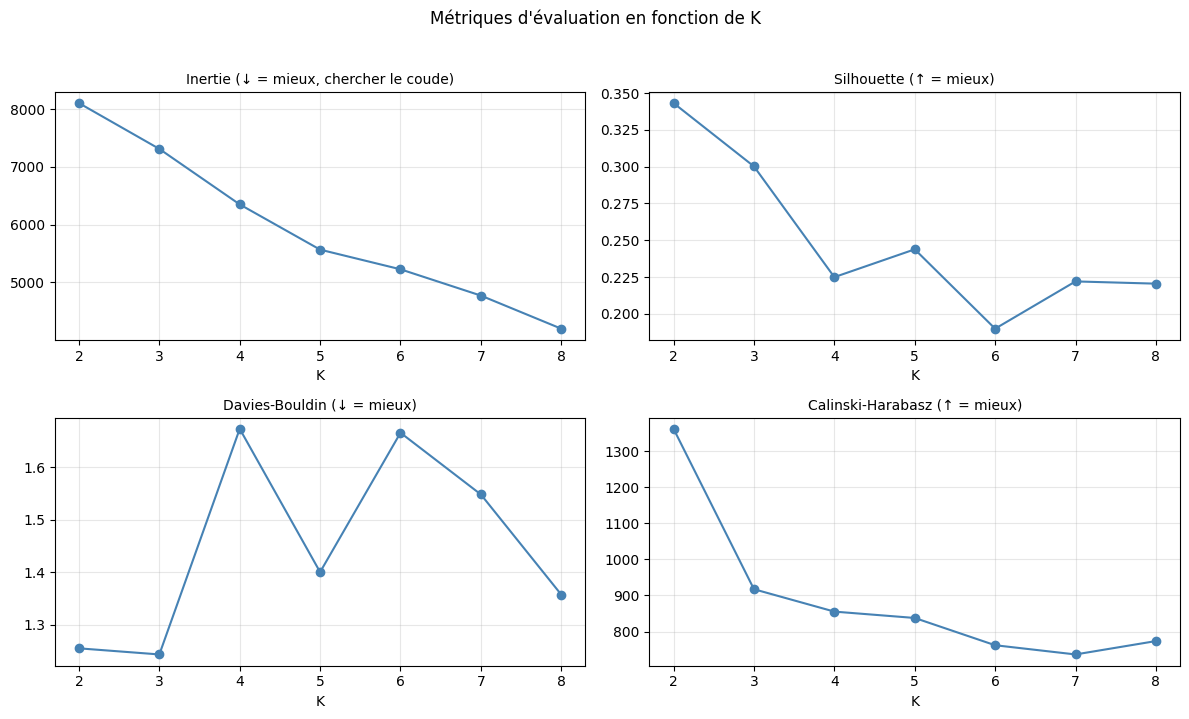

K retenu : 2  (meilleure silhouette avec min_cluster_pct >= 0.5%)


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
metrics_cfg = [
    ("inertie",           "Inertie (↓ = mieux, chercher le coude)"),
    ("silhouette",        "Silhouette (↑ = mieux)"),
    ("davies_bouldin",    "Davies-Bouldin (↓ = mieux)"),
    ("calinski_harabasz", "Calinski-Harabasz (↑ = mieux)"),
]
for ax, (m, title) in zip(axes.ravel(), metrics_cfg):
    ax.plot(k_df["K"], k_df[m], marker="o", color="steelblue")
    ax.set_xlabel("K"); ax.set_title(title, fontsize=10); ax.grid(alpha=0.3)
plt.suptitle("Métriques d'évaluation en fonction de K", y=1.02)
plt.tight_layout(); plt.show()

viable = k_df[k_df["viable_metier"] == "OK"]
if len(viable):
    k_best = int(viable.sort_values("silhouette", ascending=False).iloc[0]["K"])
else:
    k_best = int(k_df.sort_values("silhouette", ascending=False).iloc[0]["K"])
print(f"K retenu : {k_best}  (meilleure silhouette avec min_cluster_pct >= 0.5%)")

## 8. Comparaison de 3 algorithmes

On teste **3 familles** avec le même K :

| Algo | Hypothèse | Cas idéal |
|---|---|---|
| **MiniBatchKMeans** | Clusters sphériques de taille ~équilibrée | Data dense + équilibrée |
| **BisectingKMeans** | Scission hiérarchique descendante | Clusters de **tailles très différentes** (notre cas) |
| **GaussianMixture** | Mélange de gaussiennes (soft assignment) | Clusters qui se chevauchent |

On entraîne sur l'échantillon représentatif des clients ACTIVE (fit) et on prédit sur le full ACTIVE (transform), puis on compare.

In [20]:
algos = {
    "MiniBatchKMeans": MiniBatchKMeans(n_clusters=k_best, random_state=RANDOM_STATE,
                                        batch_size=min(4096, len(X_k)), n_init=10, max_iter=300),
    "BisectingKMeans": BisectingKMeans(n_clusters=k_best, random_state=RANDOM_STATE,
                                        n_init=3),
    "GaussianMixture": GaussianMixture(n_components=k_best, random_state=RANDOM_STATE,
                                        covariance_type="full", n_init=3, max_iter=200),
}

algo_scores = []
algo_labels_full = {}
for name, model in algos.items():
    model.fit(X_k)
    labs = model.predict(X)
    sizes = np.bincount(labs, minlength=k_best)
    sil = silhouette_score(X_k, model.predict(X_k), sample_size=sil_sample, random_state=RANDOM_STATE)
    db  = davies_bouldin_score(X_k, model.predict(X_k))
    ch  = calinski_harabasz_score(X_k, model.predict(X_k))
    algo_scores.append({
        "algo": name,
        "silhouette": round(sil, 4),
        "davies_bouldin": round(db, 4),
        "calinski_harabasz": round(ch, 1),
        "min_size_pct": round(sizes.min() / len(labs) * 100, 2),
        "max_size_pct": round(sizes.max() / len(labs) * 100, 2),
        "size_ratio":   round(sizes.max() / max(sizes.min(), 1), 1),
    })
    algo_labels_full[name] = labs

comparison = pd.DataFrame(algo_scores)
comparison

,algo,silhouette,davies_bouldin,calinski_harabasz,min_size_pct,max_size_pct,size_ratio
0,MiniBatchKMeans,0.343,1.255,1362.200,28.300,71.700,2.500
1,BisectingKMeans,0.343,1.255,1362.200,28.300,71.700,2.500
2,GaussianMixture,0.343,1.253,1361.800,28.240,71.760,2.500


### 8.1 Sélection de l'algo retenu

**Critère de décision** (ordre de priorité) :

1. `min_size_pct >= 0.5%` (contrainte métier dure — on élimine ceux qui ne la respectent pas).
2. `size_ratio` le plus faible possible (on évite un géant + des miettes).
3. À égalité, meilleure `silhouette`.

In [21]:
viable = comparison[comparison["min_size_pct"] >= 0.5].copy()
if len(viable) == 0:
    viable = comparison.copy()

viable = viable.sort_values(["size_ratio", "silhouette"], ascending=[True, False])
best_algo = viable.iloc[0]["algo"]
print(f"Algo retenu : {best_algo}")

labels = algo_labels_full[best_algo]
df_active["cluster_id"] = labels

cluster_sizes = pd.Series(labels).value_counts().sort_index()
cluster_pct = (cluster_sizes / len(labels) * 100).round(2)
cluster_distrib = pd.DataFrame({"count": cluster_sizes, "pct": cluster_pct})
print("\nRépartition finale :")
print(cluster_distrib)

Algo retenu : MiniBatchKMeans

Répartition finale :
   count    pct
0   6602 71.700
1   2606 28.300


## 9. Interprétation et nommage automatique

**Méthode** — pour chaque cluster on calcule le **z-score** de chaque feature (écart à la moyenne ACTIVE, en nombre d'écarts-types). Les features avec `|z| > 0.5` sont les **traits distinctifs** du cluster.

Le nom du cluster est construit depuis ces traits via des règles métier :

```
z(NB_SOS) > +0.5          →  "SOS-heavy"
z(debt_to_credit) > +0.5  →  "Endetté"
z(reimburse_ratio) > +0.5 →  "Bon-payeur"
z(reimburse_ratio) < -0.5 →  "Mauvais-payeur"
z(AVG_DAYS_SINCE_CREDIT) > +0.5 → "Latent"
z(credit_intensity) > +0.5 →  "Intensif"
```

Un cluster peut avoir plusieurs tags combinés (ex. "Intensif + Mauvais-payeur") → ce sont les **segments actionnables** pour le système multi-agents.

In [22]:
PROFILE_COLS = [
    "AVG_CREDIT_AMOUNT", "reimburse_ratio", "AVG_DAYS_SINCE_CREDIT",
    "TOTAL_OUTSTANDING_AMOUNT", "NB_SOS", "debt_to_credit",
    "credit_intensity", "tenure_days", "has_debt", "uses_sos",
    "never_repaid", "full_repayer", "is_dormant_like",
]

profile_mean = df_active.groupby("cluster_id")[PROFILE_COLS].mean()

pop_mean = df_active[PROFILE_COLS].mean()
pop_std  = df_active[PROFILE_COLS].std().replace(0, 1)
zscores  = (profile_mean - pop_mean) / pop_std

print("Profils moyens par cluster :")
display_profile = profile_mean.copy()
display_profile["size"] = df_active.groupby("cluster_id").size()
display_profile["pct"] = (display_profile["size"] / len(df_active) * 100).round(2)
display_profile.round(2)

Profils moyens par cluster :


,AVG_CREDIT_AMOUNT,reimburse_ratio,AVG_DAYS_SINCE_CREDIT,TOTAL_OUTSTANDING_AMOUNT,NB_SOS,debt_to_credit,credit_intensity,tenure_days,has_debt,uses_sos,never_repaid,full_repayer,is_dormant_like,size,pct
cluster_id,,,,,,,,,,,,,,,
0,2.070,0.720,44.050,7.280,22.260,4.060,0.800,2138.420,0.980,1.000,0.050,0.090,0.000,6602,71.700
1,2.350,1.000,50.230,0.000,4.400,0.000,0.210,2193.560,0.000,1.000,0.000,1.000,0.000,2606,28.300


In [23]:
print("Z-scores (écart à la moyenne ACTIVE, en écarts-types) :")
zscores.round(2)

Z-scores (écart à la moyenne ACTIVE, en écarts-types) :


,AVG_CREDIT_AMOUNT,reimburse_ratio,AVG_DAYS_SINCE_CREDIT,TOTAL_OUTSTANDING_AMOUNT,NB_SOS,debt_to_credit,credit_intensity,tenure_days,has_debt,uses_sos,never_repaid,full_repayer,is_dormant_like
cluster_id,,,,,,,,,,,,,
0,-0.040,-0.330,-0.110,0.270,0.210,0.280,0.140,-0.010,0.610,0.000,0.080,-0.540,0.000
1,0.090,0.850,0.270,-0.680,-0.540,-0.720,-0.350,0.020,-1.530,0.000,-0.190,1.370,0.000


In [24]:
Z_THRESHOLD = 0.5

def name_cluster(z_row: pd.Series) -> str:
    tags = []
    if z_row.get("NB_SOS", 0) > Z_THRESHOLD:                tags.append("SOS-heavy")
    if z_row.get("debt_to_credit", 0) > Z_THRESHOLD:        tags.append("Endetté")
    if z_row.get("TOTAL_OUTSTANDING_AMOUNT", 0) > Z_THRESHOLD and "Endetté" not in tags:
        tags.append("Encours-élevé")
    if z_row.get("reimburse_ratio", 0) > Z_THRESHOLD:       tags.append("Bon-payeur")
    if z_row.get("reimburse_ratio", 0) < -Z_THRESHOLD:      tags.append("Mauvais-payeur")
    if z_row.get("AVG_DAYS_SINCE_CREDIT", 0) > Z_THRESHOLD: tags.append("Latent")
    if z_row.get("credit_intensity", 0) > Z_THRESHOLD:      tags.append("Intensif")
    if z_row.get("AVG_CREDIT_AMOUNT", 0) > Z_THRESHOLD:     tags.append("Gros-ticket")
    if z_row.get("tenure_days", 0) > Z_THRESHOLD:           tags.append("Ancien")
    if z_row.get("is_dormant_like", 0) > Z_THRESHOLD:       tags.append("Dormant-like")

    if not tags:
        return "Standard"
    return " + ".join(tags[:3])

cluster_names = {cid: name_cluster(zscores.loc[cid]) for cid in zscores.index}
df_active["cluster_name"] = df_active["cluster_id"].map(cluster_names)

summary = (
    df_active.groupby(["cluster_id", "cluster_name"])
      .size().reset_index(name="count")
)
summary["pct"] = (summary["count"] / len(df_active) * 100).round(2)
summary.sort_values("count", ascending=False)

,cluster_id,cluster_name,count,pct
0,0,Standard,6602,71.700
1,1,Bon-payeur,2606,28.300


### 9.1 Visualisations : heatmap + PCA 2D

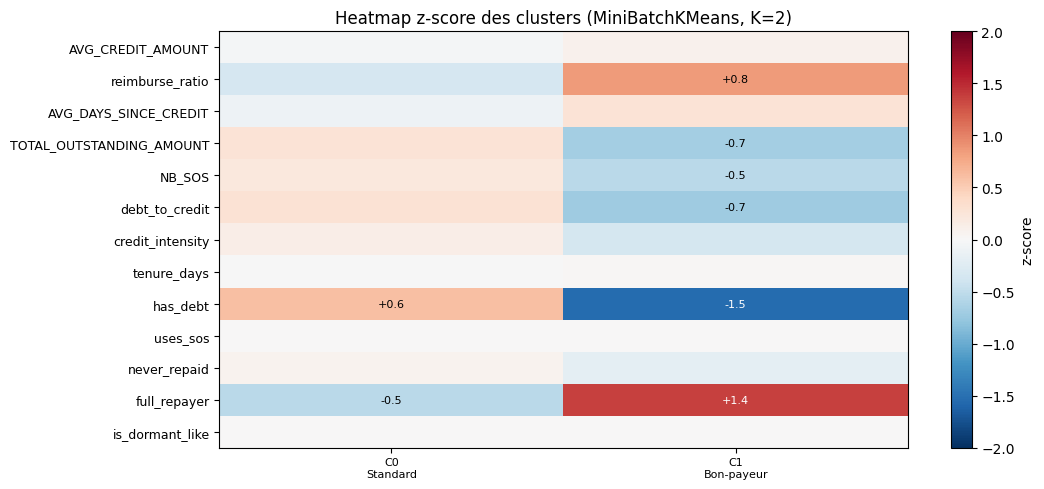

In [25]:
fig, ax = plt.subplots(figsize=(11, 5))
z_plot = zscores.T.values
im = ax.imshow(z_plot, cmap="RdBu_r", vmin=-2, vmax=2, aspect="auto")
ax.set_yticks(range(len(PROFILE_COLS))); ax.set_yticklabels(PROFILE_COLS, fontsize=9)
x_labels = [f"C{cid}\n{cluster_names[cid]}" for cid in zscores.index]
ax.set_xticks(range(len(x_labels))); ax.set_xticklabels(x_labels, fontsize=8)
for i in range(z_plot.shape[0]):
    for j in range(z_plot.shape[1]):
        if abs(z_plot[i, j]) >= Z_THRESHOLD:
            ax.text(j, i, f"{z_plot[i, j]:+.1f}", ha="center", va="center",
                    fontsize=8, color="white" if abs(z_plot[i, j]) > 1.2 else "black")
plt.colorbar(im, ax=ax, label="z-score")
ax.set_title(f"Heatmap z-score des clusters ({best_algo}, K={k_best})")
plt.tight_layout(); plt.show()

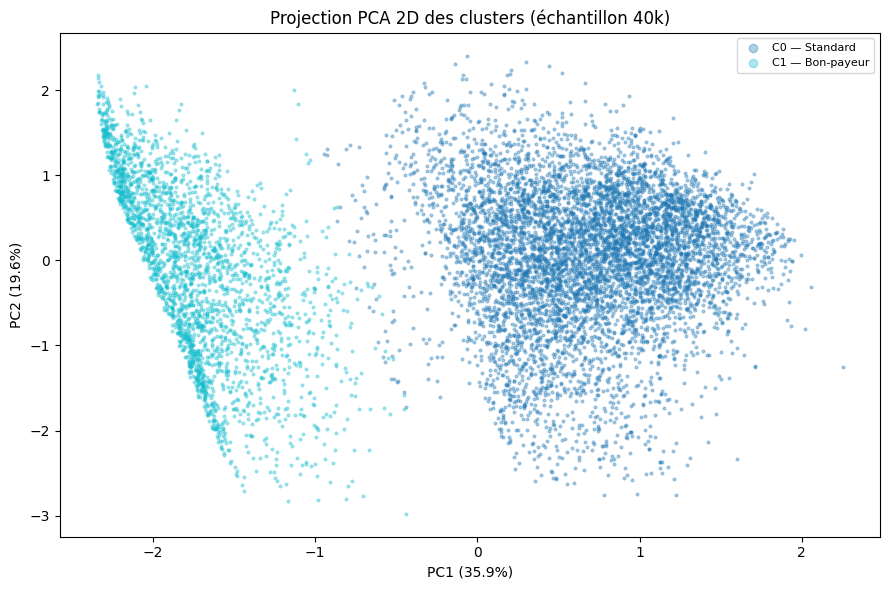

In [26]:
pca_idx = rng.choice(len(X), size=min(40_000, len(X)), replace=False)
pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(X[pca_idx])
X_pca = pca.transform(X[pca_idx])

fig, ax = plt.subplots(figsize=(9, 6))
palette = plt.cm.tab10(np.linspace(0, 1, k_best))
for cid in sorted(np.unique(labels)):
    mask = labels[pca_idx] == cid
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=4, alpha=0.35,
               color=palette[cid], label=f"C{cid} — {cluster_names[cid]}")
leg = ax.legend(markerscale=3, loc="best", fontsize=8)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("Projection PCA 2D des clusters (échantillon 40k)")
plt.tight_layout(); plt.show()

## 10. Risk Ladder — Segmentation ordinale 5 niveaux

**Objectif** : produire une **échelle de risque ordonnée** à 5 niveaux actionnables pour le système multi-agents :

| Niveau | Label | Couleur |
|---|---|---|
| 1 | Sans risque | vert |
| 2 | Normal | vert clair |
| 3 | À risque | jaune |
| 4 | Haut risque | orange |
| 5 | Blacklist | rouge |

Les **proportions finales** ne sont **pas imposées** — elles émergent naturellement des données selon les règles métier définies en 10.3.

### Pourquoi cette section vient après le clustering

Le clustering ML (sections 7-9) a répondu à **"quel type comportemental ?"** — ses sorties `cluster_id` / `cluster_name` restent. Cette section répond à **"quelle urgence d'action ?"** — c'est un axe complémentaire, pas un remplacement.

### Principe de construction (hybride)

1. **STATE** donne la première colonne vertébrale (ordonné par nature métier : ACTIVE → ON-HOLD → SUSPENDED → DISCONNECTED).
2. **`risk_score_raw`** (score métier composite de 6 signaux) **raffine** à l'intérieur de la plage ACTIVE.
3. **Flags comportementaux** (`never_repaid`, `has_debt`, `full_repayer`) ajoutent des **escalades** ou **dé-escalades** selon le profil.
4. `risk_score_final` reste calculé (pour ordonner les clients dans un export, post-analyse), mais **n'est plus la base de l'assignation**.

### Trade-off assumé

Ce n'est plus du clustering "segmentation comportementale non supervisée" — c'est du **risk tiering par règles métier + score**. Ce choix est volontaire : il donne la lisibilité ordonnée qu'exige le métier et des règles **traçables par l'agent contrôleur** (chaque niveau s'explique par une règle, pas par un seuil flou).

### 10.1 Calcul du score métier composite

On reprend la logique de `app/ml/rules.py` **inlined ici** pour que le notebook soit autonome.

Le score combine 6 signaux pondérés dans `[0, 1]` :

| Signal | Poids | Logique |
|---|---|---|
| `1 - reimburse_ratio` | 28% | Moins on rembourse, plus on est à risque |
| `outstanding` (p10→p90) | 22% | Encours élevé = risque |
| `outstanding_fee` (p10→p90) | 12% | Frais non remboursés = risque |
| `NB_SOS` (0→p95) | 15% | Usage intensif du crédit d'urgence = risque |
| `days_since_credit` (0→p90) | 13% | Latence d'usage = risque modéré |
| `avg_credit_fee` (p10→p90) | 10% | Coût du crédit = proxy de dépendance |

risk_score_raw — distribution :
count   9748.000
mean       0.293
std        0.177
min        0.013
25%        0.154
50%        0.239
75%        0.409
max        0.862
Name: risk_score_raw, dtype: float64


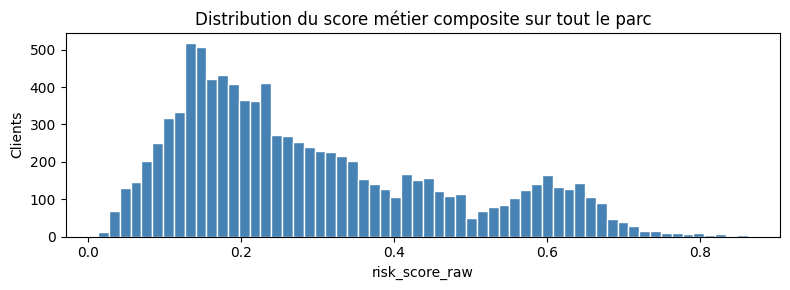

In [27]:
def _norm_high_is_risk(x, low, high):
    t = (x - low) / (high - low + 1e-9)
    return np.clip(t, 0.0, 1.0)

def _norm_low_is_risk(x, low, high):
    t = (high - x) / (high - low + 1e-9)
    return np.clip(t, 0.0, 1.0)

def compute_rule_score(frame: pd.DataFrame) -> pd.Series:
    reimburse_ratio = frame["AVG_REIMBURSE_RATIO"].to_numpy(dtype=float)
    outstanding    = frame["TOTAL_OUTSTANDING_AMOUNT"].to_numpy(dtype=float)
    outstanding_fee = frame["TOTAL_OUTSTANDING_FEE"].to_numpy(dtype=float)
    nb_sos         = frame["NB_SOS"].to_numpy(dtype=float)
    days_since     = frame["AVG_DAYS_SINCE_CREDIT"].to_numpy(dtype=float)
    avg_fee        = frame["AVG_CREDIT_FEE"].to_numpy(dtype=float)

    s_ratio    = _norm_low_is_risk(reimburse_ratio, low=0.15, high=0.85)
    s_out      = _norm_high_is_risk(outstanding,     low=np.percentile(outstanding, 10),     high=np.percentile(outstanding, 90))
    s_fee_out  = _norm_high_is_risk(outstanding_fee, low=np.percentile(outstanding_fee, 10), high=np.percentile(outstanding_fee, 90))
    s_sos      = _norm_high_is_risk(nb_sos,          low=0.0, high=max(5.0, float(np.percentile(nb_sos, 95))))
    s_days     = _norm_high_is_risk(days_since,      low=0.0, high=max(60.0, float(np.percentile(days_since, 90))))
    s_fee      = _norm_high_is_risk(avg_fee,         low=np.percentile(avg_fee, 10), high=np.percentile(avg_fee, 90))

    weights = np.array([0.28, 0.22, 0.12, 0.15, 0.13, 0.10])
    parts = np.vstack([s_ratio, s_out, s_fee_out, s_sos, s_days, s_fee])
    score = (parts.T * weights).sum(axis=1)
    return pd.Series(np.clip(score, 0.0, 1.0), index=frame.index)

df["risk_score_raw"] = compute_rule_score(df)

print(f"risk_score_raw — distribution :")
print(df["risk_score_raw"].describe().round(3))

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(df["risk_score_raw"], bins=60, color="steelblue", edgecolor="white")
ax.set_xlabel("risk_score_raw"); ax.set_ylabel("Clients")
ax.set_title("Distribution du score métier composite sur tout le parc")
plt.tight_layout(); plt.show()

### 10.2 Score final ordinal par bandes STATE

On mappe chaque STATE sur une **plage de score réservée**. Cela garantit :

- qu'un `DISCONNECTED` (plage [0.93, 1.00]) est **toujours** au-dessus d'un `ACTIVE` (plage [0.00, 0.70]),
- que dans chaque STATE, le `risk_score` métier ordonne finement les clients.

```
score_final = lo_bande(STATE) + risk_score × (hi_bande - lo_bande)
```

In [28]:
STATE_BANDS = {
    "ACTIVE":       (0.00, 0.70),
    "ON-HOLD":      (0.70, 0.80),
    "SUSPENDED":    (0.85, 0.93),
    "DISCONNECTED": (0.93, 1.00),
    "OTHER":        (0.70, 0.80),
}

lo = df["STATE"].map(lambda s: STATE_BANDS.get(s, STATE_BANDS["OTHER"])[0]).to_numpy()
hi = df["STATE"].map(lambda s: STATE_BANDS.get(s, STATE_BANDS["OTHER"])[1]).to_numpy()
df["risk_score_final"] = lo + (hi - lo) * df["risk_score_raw"].to_numpy()

print("risk_score_final — range par STATE (min / max) :")
print(df.groupby("STATE")["risk_score_final"].agg(["min", "max", "mean", "count"]).round(3))

risk_score_final — range par STATE (min / max) :
               min   max  mean  count
STATE                                
ACTIVE       0.015 0.603 0.205   9208
DISCONNECTED 0.940 0.988 0.958     28
ON-HOLD      0.729 0.751 0.743     15
SUSPENDED    0.851 0.919 0.872    497


### 10.3 Assignation du niveau par règles métier

Les 5 niveaux sont définis par **des règles claires combinant STATE + comportement**, pas par des seuils de pourcentage forcés. Les proportions finales reflètent la **réalité** du parc.

| Niveau | Règle | Logique métier |
|---|---|---|
| **5 — Blacklist** | `STATE ∈ {SUSPENDED, DISCONNECTED}` | Compte bloqué ou résilié → perdu ou gelé |
| **4 — Haut risque** | `STATE = ON-HOLD` **OU** (`STATE = ACTIVE` **ET** (`never_repaid=1` **OU** `risk_score_raw ≥ 0.65`)) | Signaux de dégradation forte, action urgente |
| **3 — À risque** | `STATE = ACTIVE` **ET** `has_debt=1` **ET** `risk_score_raw ≥ 0.35` | Endetté avec score métier moyen/haut |
| **1 — Sans risque** | `STATE = ACTIVE` **ET** `full_repayer=1` **ET** `has_debt=0` **ET** `risk_score_raw < 0.20` | Bon-payeur propre, pas de dette |
| **2 — Normal** | Tous les autres ACTIVE | Comportement correct sans signal fort |

**Ordre d'évaluation** : on commence par les cas les plus graves (Blacklist → Haut risque → À risque → Sans risque) et "Normal" est le bucket par défaut pour les ACTIVE qui ne déclenchent aucune règle. Cela garantit qu'un client marqué "Haut risque" ne peut pas se retrouver en "Normal".

In [29]:
LABELS = {
    1: "Sans risque",
    2: "Normal",
    3: "A risque",
    4: "Haut risque",
    5: "Blacklist",
}

HIGH_SCORE_THR = 0.65
MID_SCORE_THR  = 0.35
LOW_SCORE_THR  = 0.20

def assign_level_rules(row):
    state = row["STATE"]
    score = row["risk_score_raw"]

    if state in ("SUSPENDED", "DISCONNECTED", "OTHER"):
        return 5

    if state == "ON-HOLD":
        return 4
    if state == "ACTIVE" and (row.get("never_repaid", 0) == 1 or score >= HIGH_SCORE_THR):
        return 4

    if state == "ACTIVE" and row.get("has_debt", 0) == 1 and score >= MID_SCORE_THR:
        return 3

    if (state == "ACTIVE"
        and row.get("full_repayer", 0) == 1
        and row.get("has_debt", 0) == 0
        and score < LOW_SCORE_THR):
        return 1

    return 2

df["risk_level"] = df.apply(assign_level_rules, axis=1).astype(int)
df["risk_label"] = df["risk_level"].map(LABELS)

obtained = df["risk_level"].value_counts().sort_index()
obtained_pct = (obtained / len(df) * 100).round(2)
distrib = pd.DataFrame({
    "level": [k for k in range(1, 6)],
    "label": [LABELS[k] for k in range(1, 6)],
    "count": [int(obtained.get(k, 0)) for k in range(1, 6)],
    "pct":   [obtained_pct.get(k, 0.0) for k in range(1, 6)],
})
print("Distribution réelle du Risk Ladder (selon règles métier) :")
distrib

Distribution réelle du Risk Ladder (selon règles métier) :


,level,label,count,pct
0,1,Sans risque,2338,23.980
1,2,Normal,3980,40.830
2,3,A risque,2197,22.540
3,4,Haut risque,708,7.260
4,5,Blacklist,525,5.390


### 10.4 Visualisation du Risk Ladder

Camembert + barres avec les couleurs métier standard (vert → rouge).

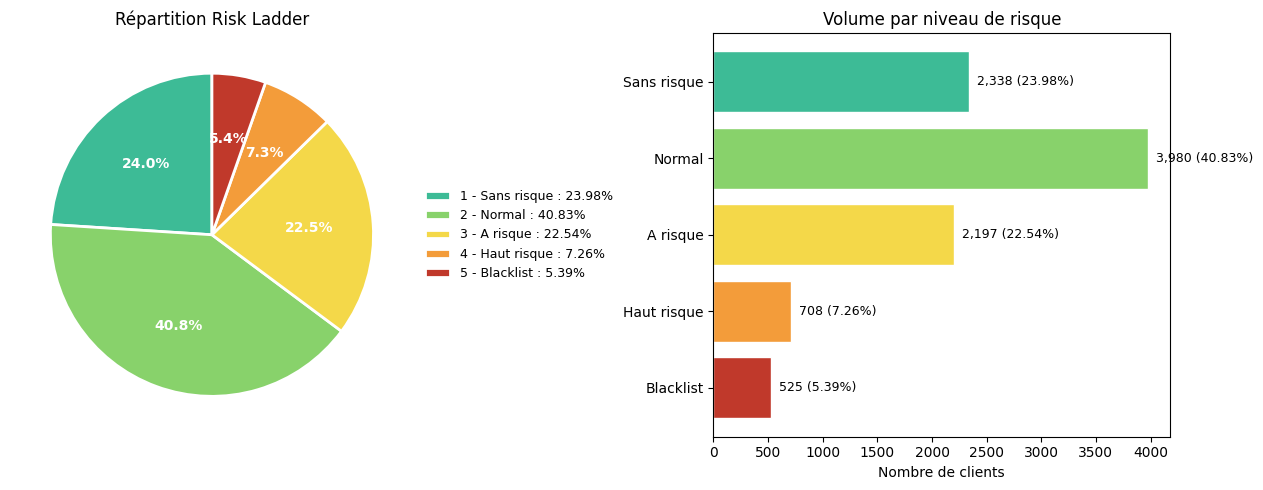

In [30]:
COLORS = {
    1: "#3DBB96",
    2: "#88D26B",
    3: "#F4D849",
    4: "#F39C3A",
    5: "#C0392B",
}

level_counts = df["risk_level"].value_counts().sort_index()
level_pct = (level_counts / len(df) * 100).round(2)
palette = [COLORS[k] for k in level_counts.index]
legend_labels = [f"{k} - {LABELS[k]} : {level_pct[k]:.2f}%" for k in level_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(level_counts.values, colors=palette, startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2),
            autopct=lambda p: f"{p:.1f}%", textprops=dict(color="white", fontsize=10, fontweight="bold"))
axes[0].set_title("Répartition Risk Ladder")
axes[0].legend(legend_labels, loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=9, frameon=False)

bars = axes[1].barh(range(len(level_counts))[::-1], level_counts.values,
                     color=palette, edgecolor="white")
axes[1].set_yticks(range(len(level_counts))[::-1])
axes[1].set_yticklabels([LABELS[k] for k in level_counts.index], fontsize=10)
for i, (k, v) in enumerate(level_counts.items()):
    axes[1].text(v, len(level_counts) - 1 - i,
                 f"  {v:,} ({level_pct[k]:.2f}%)", va="center", fontsize=9)
axes[1].set_xlabel("Nombre de clients")
axes[1].set_title("Volume par niveau de risque")

plt.tight_layout(); plt.show()

### 10.5 Cohérence Risk Level × STATE × Cluster ML

On vérifie que le mapping est sensé :

- **STATE × risk_level** : DISCONNECTED doit être 100% en niveau 5, ACTIVE réparti sur 1→3 (+ un peu 4/5 pour les pires scores).
- **cluster_name × risk_level** (sur ACTIVE) : les "Bon-payeur" doivent dominer les niveaux 1-2, les "Standard" se répartir selon leur score.

In [31]:
crosstab_state = pd.crosstab(df["STATE"], df["risk_label"],
                              normalize="index").reindex(columns=[LABELS[k] for k in range(1, 6)]).fillna(0)
print("STATE × risk_label (proportions par ligne, % dans chaque STATE) :")
(crosstab_state * 100).round(1)

STATE × risk_label (proportions par ligne, % dans chaque STATE) :


risk_label,Sans risque,Normal,A risque,Haut risque,Blacklist
STATE,,,,,
ACTIVE,25.400,43.200,23.900,7.500,0.000
DISCONNECTED,0.000,0.000,0.000,0.000,100.000
ON-HOLD,0.000,0.000,0.000,100.000,0.000
SUSPENDED,0.000,0.000,0.000,0.000,100.000


In [32]:
active_mask = df["STATE"] == "ACTIVE"
for col in ("risk_score_raw", "risk_score_final", "risk_level", "risk_label"):
    df_active[col] = df.loc[active_mask, col].values

crosstab_ml = pd.crosstab(df_active["cluster_name"], df_active["risk_label"],
                           normalize="index").reindex(columns=[LABELS[k] for k in range(1, 6)]).fillna(0)
print("cluster_name (ML) × risk_label sur ACTIVE (proportions par ligne) :")
(crosstab_ml * 100).round(1)

cluster_name (ML) × risk_label sur ACTIVE (proportions par ligne) :


risk_label,Sans risque,Normal,A risque,Haut risque,Blacklist
cluster_name,,,,,
Bon-payeur,85.400,14.600,0.000,0.000,0.000
Standard,1.700,54.500,33.300,10.500,0.000


## 11. Anomalies + dataset final

**Isolation Forest** tourne sur **le même X transformé** que le clustering (cohérence : un point est "anormal" dans le même espace où il est "segmenté").

Contamination = 3% → on isole les 3% de comportements atypiques (fraudes potentielles, bots, erreurs de saisie) **en plus** de leur cluster et de leur risk_level.

Enfin on reconstruit le **dataset complet** (ACTIVE + non-ACTIVE) en agrégeant toutes les sorties : `cluster_name`, `risk_level`, `anomaly_flag`.

In [33]:
iso = IsolationForest(
    contamination=0.03,
    random_state=RANDOM_STATE,
    n_estimators=200,
    max_samples=min(5000, len(X)),
    n_jobs=1,
)
iso.fit(X)

df_active["anomaly_flag"] = (iso.predict(X) == -1).astype(int)
df_active["anomaly_score"] = -iso.score_samples(X)

print(f"Anomalies détectées : {df_active['anomaly_flag'].sum():,} "
      f"({df_active['anomaly_flag'].mean():.2%})")

print("\nAnomalies par cluster :")
anom_breakdown = df_active.groupby(["cluster_id", "cluster_name"]).agg(
    total=("anomaly_flag", "size"),
    anomalies=("anomaly_flag", "sum"),
)
anom_breakdown["pct_anomalies"] = (anom_breakdown["anomalies"] / anom_breakdown["total"] * 100).round(2)
anom_breakdown


Anomalies détectées : 277 (3.01%)

Anomalies par cluster :


,,total,anomalies,pct_anomalies
cluster_id,cluster_name,,,
0,Standard,6602,252,3.820
1,Bon-payeur,2606,25,0.960


### 11.1 Visualisation des anomalies

Deux vues complémentaires :

1. **Distribution du `anomaly_score`** — on vérifie que le seuil 3% isole bien une queue de distribution et pas un bloc central.
2. **Projection PCA 2D** avec les anomalies en rouge — elles doivent être aux **frontières des clusters** ou **isolées** en périphérie, pas au cœur d'un cluster.

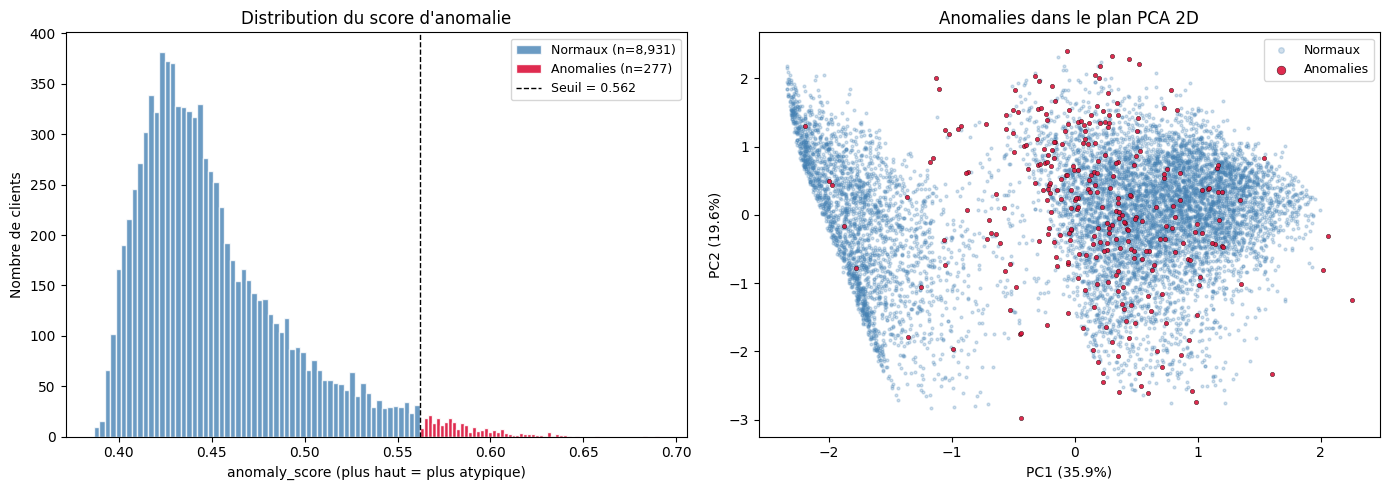


Top 5 clients les plus atypiques :


,MSISDN,cluster_name,risk_label,AVG_CREDIT_AMOUNT,TOTAL_OUTSTANDING_AMOUNT,NB_SOS,reimburse_ratio,anomaly_score
0,21699537053,Standard,Haut risque,0.657,9.200,14,0.000,0.691
1,21697827668,Standard,Haut risque,0.250,0.750,3,0.000,0.683
2,21698603478,Standard,Haut risque,0.478,4.300,9,0.000,0.657
3,21693903430,Standard,Haut risque,1.168,29.200,25,0.000,0.646
4,21698606971,Bon-payeur,Normal,4.180,0.000,5,1.000,0.641


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scores = df_active["anomaly_score"].to_numpy()
flags  = df_active["anomaly_flag"].to_numpy()
threshold = scores[flags == 1].min() if flags.sum() > 0 else None

axes[0].hist(scores[flags == 0], bins=60, color="steelblue", edgecolor="white",
             label=f"Normaux (n={int((flags == 0).sum()):,})", alpha=0.8)
axes[0].hist(scores[flags == 1], bins=60, color="crimson",  edgecolor="white",
             label=f"Anomalies (n={int(flags.sum()):,})", alpha=0.9)
if threshold is not None:
    axes[0].axvline(threshold, color="black", linestyle="--", linewidth=1,
                    label=f"Seuil = {threshold:.3f}")
axes[0].set_xlabel("anomaly_score (plus haut = plus atypique)")
axes[0].set_ylabel("Nombre de clients")
axes[0].set_title("Distribution du score d'anomalie")
axes[0].legend(fontsize=9)

sample_n = min(40_000, len(X))
idx_viz = rng.choice(len(X), size=sample_n, replace=False)
X_viz = pca.transform(X[idx_viz])
flags_viz = flags[idx_viz]

axes[1].scatter(X_viz[flags_viz == 0, 0], X_viz[flags_viz == 0, 1],
                s=4, alpha=0.25, color="steelblue", label="Normaux")
axes[1].scatter(X_viz[flags_viz == 1, 0], X_viz[flags_viz == 1, 1],
                s=10, alpha=0.9, color="crimson", label="Anomalies",
                edgecolor="black", linewidth=0.3)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[1].set_title("Anomalies dans le plan PCA 2D")
axes[1].legend(fontsize=9, markerscale=2)

plt.tight_layout(); plt.show()

print(f"\nTop 5 clients les plus atypiques :")
top_anom = df_active.nlargest(5, "anomaly_score")[
    ["MSISDN", "cluster_name", "risk_label",
     "AVG_CREDIT_AMOUNT", "TOTAL_OUTSTANDING_AMOUNT", "NB_SOS",
     "reimburse_ratio", "anomaly_score"]
].reset_index(drop=True)
top_anom

### 11.2 Fusion ACTIVE (ML) + non-ACTIVE (déterministe)

Pour les non-ACTIVE, on attribue :
- `cluster_id = -1` (convention : "pas soumis au clustering ML")
- `cluster_name = STATE` (SUSPENDED / ON-HOLD / DISCONNECTED / OTHER)
- Pas d'anomalie calculée (`anomaly_flag = 0`) — leur statut administratif est déjà l'information principale.

En revanche **tous les clients** (ACTIVE et non-ACTIVE) portent `risk_level` / `risk_label` / `risk_score_raw` / `risk_score_final` calculés dans la section 10.

In [35]:
df_other = df[df["STATE"] != "ACTIVE"].copy().reset_index(drop=True)
df_other["cluster_id"] = -1
df_other["cluster_name"] = df_other["STATE"]
df_other["anomaly_flag"] = 0
df_other["anomaly_score"] = 0.0

KEEP_COLS = [
    "MSISDN", "STATE",
    "AVG_CREDIT_AMOUNT", "reimburse_ratio",
    "AVG_DAYS_SINCE_CREDIT", "TOTAL_OUTSTANDING_AMOUNT", "NB_SOS",
    "debt_to_credit", "credit_intensity", "tenure_days",
    "has_debt", "uses_sos", "never_repaid", "full_repayer", "is_dormant_like",
    "cluster_id", "cluster_name",
    "risk_score_raw", "risk_score_final", "risk_level", "risk_label",
    "anomaly_flag", "anomaly_score",
]

final_df = pd.concat([df_active[KEEP_COLS], df_other[KEEP_COLS]], ignore_index=True)

print(f"Dataset final : {len(final_df):,} lignes x {final_df.shape[1]} colonnes")

print("\nSegmentation comportementale (cluster_name) :")
seg = final_df.groupby(["cluster_id", "cluster_name"]).size().reset_index(name="count")
seg["pct"] = (seg["count"] / len(final_df) * 100).round(2)
print(seg.sort_values("count", ascending=False).to_string(index=False))

print("\nRisk ladder (risk_level) :")
lad = final_df.groupby(["risk_level", "risk_label"]).size().reset_index(name="count")
lad["pct"] = (lad["count"] / len(final_df) * 100).round(2)
print(lad.to_string(index=False))

Dataset final : 9,748 lignes x 23 colonnes

Segmentation comportementale (cluster_name) :
 cluster_id cluster_name  count    pct
          0     Standard   6602 67.730
          1   Bon-payeur   2606 26.730
         -1    SUSPENDED    497  5.100
         -1 DISCONNECTED     28  0.290
         -1      ON-HOLD     15  0.150

Risk ladder (risk_level) :
 risk_level  risk_label  count    pct
          1 Sans risque   2338 23.980
          2      Normal   3980 40.830
          3    A risque   2197 22.540
          4 Haut risque    708  7.260
          5   Blacklist    525  5.390


### 11.3 Dashboard final — segmentation croisée

Vue **3D** en un seul tableau : chaque client est caractérisé par le triplet (`cluster_name`, `risk_label`, `anomaly_flag`).

La heatmap ci-dessous montre **combien de clients** tombent dans chaque couple `cluster_name × risk_label`. C'est ce tableau que les agents métier vont interroger pour router les actions.

Pivot cluster_name x risk_label (nombre de clients) :
risk_label    Sans risque  Normal  A risque  Haut risque  Blacklist
cluster_name                                                       
Bon-payeur           2225     381         0            0          0
Standard              113    3599      2197          693          0
ON-HOLD                 0       0         0           15          0
SUSPENDED               0       0         0            0        497
DISCONNECTED            0       0         0            0         28


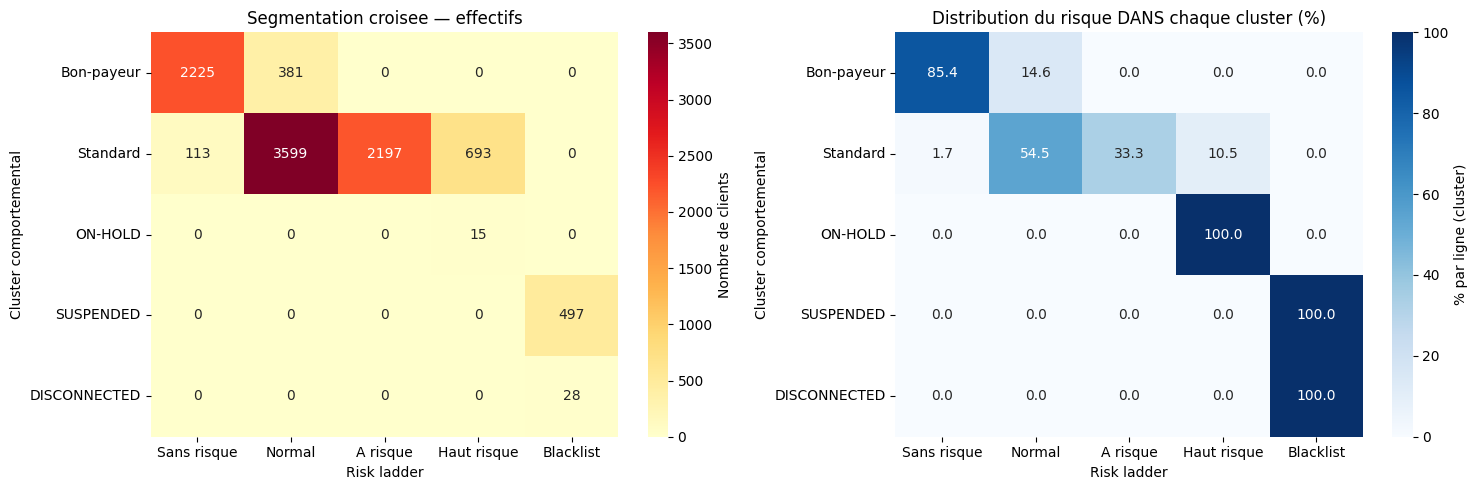


Anomalies par couple cluster x risk :
risk_label    Sans risque  Normal  A risque  Haut risque
cluster_name                                            
Bon-payeur             10      15         0            0
Standard               22      93        37          100


In [36]:
LABEL_ORDER = ["Sans risque", "Normal", "A risque", "Haut risque", "Blacklist"]
CLUSTER_ORDER = ["Bon-payeur", "Standard", "ON-HOLD", "SUSPENDED", "DISCONNECTED", "OTHER"]

pivot = (final_df
         .groupby(["cluster_name", "risk_label"])
         .size()
         .unstack(fill_value=0))

pivot = pivot.reindex(
    index=[c for c in CLUSTER_ORDER if c in pivot.index],
    columns=[l for l in LABEL_ORDER if l in pivot.columns],
    fill_value=0,
)

print("Pivot cluster_name x risk_label (nombre de clients) :")
print(pivot.to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd",
            cbar_kws={"label": "Nombre de clients"}, ax=axes[0])
axes[0].set_title("Segmentation croisee — effectifs")
axes[0].set_xlabel("Risk ladder"); axes[0].set_ylabel("Cluster comportemental")

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
sns.heatmap(pivot_pct, annot=True, fmt=".1f", cmap="Blues",
            cbar_kws={"label": "% par ligne (cluster)"}, ax=axes[1])
axes[1].set_title("Distribution du risque DANS chaque cluster (%)")
axes[1].set_xlabel("Risk ladder"); axes[1].set_ylabel("Cluster comportemental")

plt.tight_layout(); plt.show()

print("\nAnomalies par couple cluster x risk :")
anom_pivot = (final_df[final_df["anomaly_flag"] == 1]
              .groupby(["cluster_name", "risk_label"])
              .size()
              .unstack(fill_value=0))
if not anom_pivot.empty:
    anom_pivot = anom_pivot.reindex(
        index=[c for c in CLUSTER_ORDER if c in anom_pivot.index],
        columns=[l for l in LABEL_ORDER if l in anom_pivot.columns],
        fill_value=0,
    )
    print(anom_pivot.to_string())

## 12. Contrat de sortie pour le systeme multi-agents

Le CSV final doit etre consommable **sans transformation** par `app/agents/graph.py`.
Les agents attendent un schema precis (`AgentState.ml_outputs`, `AgentState.features`) :

| Cle attendue | Type | Source notebook | Transformation |
|---|---|---|---|
| `msisdn` | str | `MSISDN` | renommage en minuscule |
| `cluster_id` | int | `cluster_id` | direct |
| `risk_tier` | `{"low","medium","high"}` | `risk_label` (5 niveaux) | mapping 5 -> 3 |
| `final_risk_score` | float | `risk_score_final` | renommage |
| `is_anomaly` | bool | `anomaly_flag` | cast bool |
| `top_drivers` | list[{feature, value, z_score}] | calcule a partir de la pop. ACTIVE | z-scores + JSON |
| `features.TOTAL_OUTSTANDING_AMOUNT` | float | idem | direct |
| `features.AVG_REIMBURSE_RATIO` | float | `reimburse_ratio` | renommage |
| `features.NB_SOS` | float | idem | direct |

**Decisions de mapping metier** :
- `Sans risque` + `Normal` -> `low` (suivi routine)
- `A risque` -> `medium` (relance / offre retention)
- `Haut risque` + `Blacklist` -> `high` (call-center prioritaire / contentieux)

On conserve **aussi** `risk_level` (1..5) et `risk_label` dans le CSV pour une future evolution des agents vers 5 niveaux sans perte d'information.


### 12.1 Mapping 5 niveaux -> 3 tiers + renommage des colonnes agents

In [37]:
RISK_TIER_MAP = {
    "Sans risque": "low",
    "Normal":      "low",
    "A risque":    "medium",
    "Haut risque": "high",
    "Blacklist":   "high",
}

final_df["risk_tier"]         = final_df["risk_label"].map(RISK_TIER_MAP)
final_df["final_risk_score"]  = final_df["risk_score_final"]
final_df["is_anomaly"]        = final_df["anomaly_flag"].astype(bool)
final_df["AVG_REIMBURSE_RATIO"] = final_df["reimburse_ratio"]

print("Distribution risk_tier (3 niveaux agents) :")
tier_dist = final_df["risk_tier"].value_counts().reindex(["low", "medium", "high"])
tier_pct  = (tier_dist / len(final_df) * 100).round(2)
print(pd.DataFrame({"count": tier_dist, "pct": tier_pct}).to_string())

print("\nCorrespondance risk_label -> risk_tier :")
print(pd.crosstab(final_df["risk_label"], final_df["risk_tier"]).to_string())

Distribution risk_tier (3 niveaux agents) :
           count    pct
risk_tier              
low         6318 64.810
medium      2197 22.540
high        1233 12.650

Correspondance risk_label -> risk_tier :
risk_tier    high   low  medium
risk_label                     
A risque        0     0    2197
Blacklist     525     0       0
Haut risque   708     0       0
Normal          0  3980       0
Sans risque     0  2338       0


### 12.2 Calcul de `top_drivers` par client

L'agent `explainability_node` (dans `app/agents/nodes.py`) utilise `top_drivers` pour justifier la decision.
Format attendu : une **liste de dict** `[{"feature": str, "value": float, "z_score": float}, ...]` tries par |z| decroissant.

On calcule les **z-scores sur la population ACTIVE** (reference metier) pour les 9 features cles, puis on garde le **top-4** par client.
Le resultat est stocke en **JSON string** dans le CSV (deserialisable par `json.loads` cote agent).

In [38]:
import json as _json

AGENT_FEATURES = [
    "AVG_CREDIT_AMOUNT",
    "TOTAL_OUTSTANDING_AMOUNT",
    "NB_SOS",
    "reimburse_ratio",
    "debt_to_credit",
    "credit_intensity",
    "has_debt",
    "never_repaid",
    "full_repayer",
]

pop_active = df_active[AGENT_FEATURES].astype(float)
mu_pop = pop_active.mean()
sigma_pop = pop_active.std().replace(0, 1.0)

print("Population de reference (ACTIVE) :")
print(f"  n = {len(pop_active):,}")
print(pd.DataFrame({"mean": mu_pop.round(3), "std": sigma_pop.round(3)}).to_string())

# Version vectorisée : plus rapide et stable qu'un apply(axis=1).
vals_df = final_df[AGENT_FEATURES].astype(float)
z_df = (vals_df - mu_pop) / sigma_pop
feature_names = np.array(AGENT_FEATURES)
vals_matrix = vals_df.to_numpy()
z_matrix = z_df.to_numpy()

top_drivers = []
for vals_row, z_row in zip(vals_matrix, z_matrix):
    order = np.argsort(np.abs(z_row))[::-1][:4]
    drivers = [
        {
            "feature": str(feature_names[j]),
            "value": round(float(vals_row[j]), 3),
            "z_score": round(float(z_row[j]), 3),
        }
        for j in order
    ]
    top_drivers.append(_json.dumps(drivers, ensure_ascii=False))

final_df["top_drivers"] = top_drivers

print("\nExemple pour le 1er client :")
print(f"  msisdn      = {final_df['MSISDN'].iloc[0]}")
print(f"  risk_tier   = {final_df['risk_tier'].iloc[0]}")
print(f"  top_drivers = {final_df['top_drivers'].iloc[0]}")


Population de reference (ACTIVE) :
  n = 9,208
                           mean    std
AVG_CREDIT_AMOUNT         2.148  2.205
TOTAL_OUTSTANDING_AMOUNT  5.220  7.672
NB_SOS                   17.203 23.906
reimburse_ratio           0.796  0.240
debt_to_credit            2.909  4.064
credit_intensity          0.634  1.222
has_debt                  0.701  0.458
never_repaid              0.036  0.187
full_repayer              0.346  0.476

Exemple pour le 1er client :
  msisdn      = 21696330926
  risk_tier   = low
  top_drivers = [{"feature": "full_repayer", "value": 0.0, "z_score": -0.728}, {"feature": "has_debt", "value": 1.0, "z_score": 0.652}, {"feature": "debt_to_credit", "value": 0.315, "z_score": -0.638}, {"feature": "TOTAL_OUTSTANDING_AMOUNT", "value": 0.8, "z_score": -0.576}]


### 12.3 Visualisation du contrat agents

Trois vues pour valider la sortie avant livraison :

1. **Pie chart `risk_tier`** -> proportion low/medium/high que les agents verront.
2. **Sankey-like `risk_label -> risk_tier`** -> ou part chaque niveau du Risk Ladder dans le mapping 3 tiers.
3. **Taux d'anomalie par tier** -> coherence : les tiers "high" doivent concentrer les anomalies.

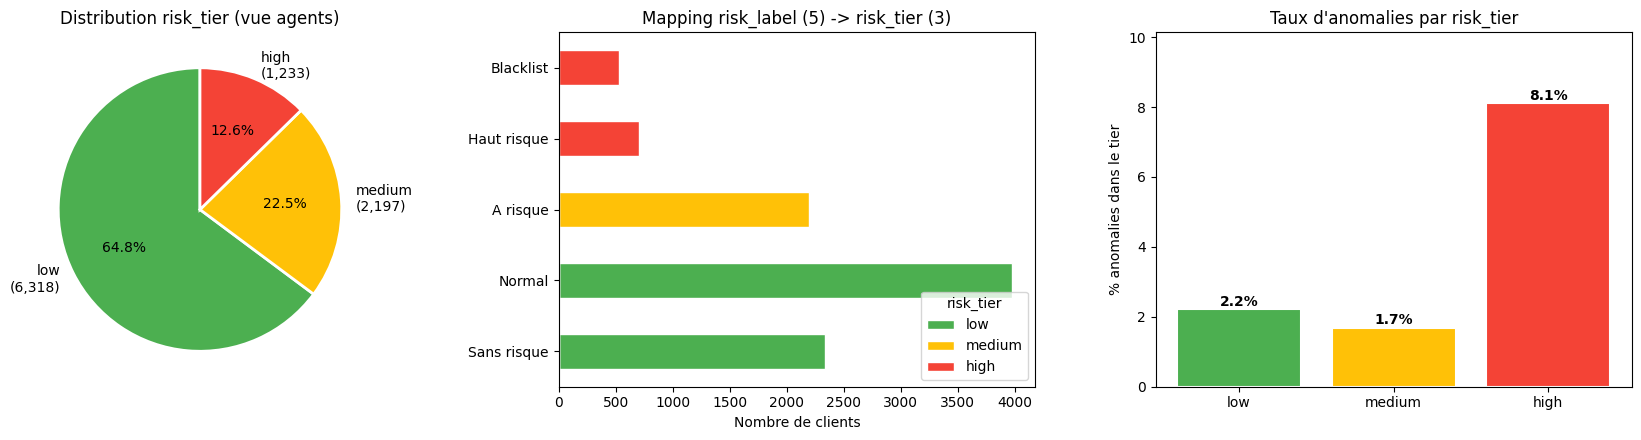

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

tier_colors = {"low": "#4CAF50", "medium": "#FFC107", "high": "#F44336"}
tier_dist = final_df["risk_tier"].value_counts().reindex(["low", "medium", "high"])

axes[0].pie(
    tier_dist,
    labels=[f"{t}\n({n:,})" for t, n in tier_dist.items()],
    autopct="%1.1f%%",
    colors=[tier_colors[t] for t in tier_dist.index],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[0].set_title("Distribution risk_tier (vue agents)")

cross = pd.crosstab(final_df["risk_label"], final_df["risk_tier"])
cross = cross.reindex(
    index=["Sans risque", "Normal", "A risque", "Haut risque", "Blacklist"],
    columns=["low", "medium", "high"],
    fill_value=0,
)
cross.plot(
    kind="barh", stacked=True, ax=axes[1],
    color=[tier_colors[t] for t in cross.columns],
    edgecolor="white",
)
axes[1].set_title("Mapping risk_label (5) -> risk_tier (3)")
axes[1].set_xlabel("Nombre de clients")
axes[1].set_ylabel("")
axes[1].legend(title="risk_tier", loc="lower right")

anom_rate = (final_df.groupby("risk_tier")["is_anomaly"].mean() * 100).reindex(["low", "medium", "high"])
axes[2].bar(
    anom_rate.index, anom_rate.values,
    color=[tier_colors[t] for t in anom_rate.index],
    edgecolor="white", linewidth=1.5,
)
for i, v in enumerate(anom_rate.values):
    axes[2].text(i, v + 0.1, f"{v:.1f}%", ha="center", fontweight="bold")
axes[2].set_ylabel("% anomalies dans le tier")
axes[2].set_title("Taux d'anomalies par risk_tier")
axes[2].set_ylim(0, max(anom_rate.max() * 1.25, 1))

plt.tight_layout(); plt.show()

### 12.4 Export CSV final aligne sur le contrat agents

Ordre des colonnes optimise pour la lisibilite : identite -> segmentation -> scores -> features -> flags.

In [40]:
# ============================================================
# Export final compatible Agentic / Backend Bad Debts
# ============================================================

AGENT_EXPORT_COLS = [
    "msisdn", "STATE",
    "cluster_id", "cluster_name",
    "risk_level", "risk_label", "risk_tier",
    "final_risk_score", "risk_score_raw",
    "is_anomaly", "anomaly_score",
    "top_drivers",
    "AVG_CREDIT_AMOUNT", "AVG_REIMBURSE_RATIO", "AVG_DAYS_SINCE_CREDIT",
    "TOTAL_OUTSTANDING_AMOUNT", "NB_SOS",
    "debt_to_credit", "credit_intensity", "tenure_days",
    "has_debt", "uses_sos", "never_repaid", "full_repayer", "is_dormant_like",
]

# Créer le dataframe final exporté
export_df = final_df.rename(columns={"MSISDN": "msisdn"}).copy()

# Vérification des colonnes attendues
missing_cols = [col for col in AGENT_EXPORT_COLS if col not in export_df.columns]

if missing_cols:
    raise ValueError(
        "Colonnes manquantes pour l'export agentic : "
        + ", ".join(missing_cols)
    )

# Garder uniquement les colonnes nécessaires à l'agent
export_df = export_df[AGENT_EXPORT_COLS]

# Dossier d'export final
OUT_DIR = Path(r'C:\\Users\\benab\\OneDrive\\Bureau\\PFE TT\\PLATEFORME TT\\backend\\runtime_data\\ml_imports\\10')
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PATH = OUT_DIR / "clients_segmented.csv"

# Export CSV final
export_df.to_csv(OUT_PATH, index=False, encoding="utf-8-sig")

print("=" * 90)
print("Export final compatible Agentic / Backend Bad Debts")
print("=" * 90)
print(f"Export OK : {OUT_PATH}")
print(f"Lignes    : {len(export_df):,}")
print(f"Colonnes  : {export_df.shape[1]}")

print("\nTypes des colonnes exportées :")
for col in AGENT_EXPORT_COLS:
    example_value = str(export_df[col].iloc[0])[:70]
    print(f"  {col:30s} {str(export_df[col].dtype):12s} exemple: {example_value}")

print("\nAperçu export :")
display(export_df.head())

Export final compatible Agentic / Backend Bad Debts
Export OK : C:\Users\benab\OneDrive\Bureau\PFE TT\PLATEFORME TT\backend\runtime_data\ml_imports\10\clients_segmented.csv
Lignes    : 9,748
Colonnes  : 25

Types des colonnes exportées :
  msisdn                         int64        exemple: 21696330926
  STATE                          object       exemple: ACTIVE
  cluster_id                     int64        exemple: 0
  cluster_name                   object       exemple: Standard
  risk_level                     int64        exemple: 2
  risk_label                     object       exemple: Normal
  risk_tier                      object       exemple: low
  final_risk_score               float64      exemple: 0.14583541335014946
  risk_score_raw                 float64      exemple: 0.20833630478592782
  is_anomaly                     bool         exemple: False
  anomaly_score                  float64      exemple: 0.4868688220343701
  top_drivers                    object       exe

,msisdn,STATE,cluster_id,cluster_name,risk_level,risk_label,risk_tier,final_risk_score,risk_score_raw,is_anomaly,anomaly_score,top_drivers,AVG_CREDIT_AMOUNT,AVG_REIMBURSE_RATIO,AVG_DAYS_SINCE_CREDIT,TOTAL_OUTSTANDING_AMOUNT,NB_SOS,debt_to_credit,credit_intensity,tenure_days,has_debt,uses_sos,never_repaid,full_repayer,is_dormant_like
0,21696330926,ACTIVE,0,Standard,2,Normal,low,0.146,0.208,False,0.487,"[{""feature"": ""full_repayer"", ""value"": 0.0, ""z_...",2.542,0.933,60.083,0.800,12,0.315,0.053,6773.000,1,1,0,0,0
1,21699807992,ACTIVE,0,Standard,3,A risque,medium,0.331,0.472,False,0.505,"[{""feature"": ""reimburse_ratio"", ""value"": 0.4, ...",3.000,0.400,14.800,9.000,5,3.000,0.820,153.000,1,1,0,0,0
2,21699128564,ACTIVE,1,Bon-payeur,1,Sans risque,low,0.087,0.124,False,0.488,"[{""feature"": ""has_debt"", ""value"": 0.0, ""z_scor...",2.500,1.000,31.000,0.000,7,0.000,1.141,154.000,0,1,0,1,0
3,21696139573,ACTIVE,0,Standard,4,Haut risque,high,0.246,0.351,True,0.573,"[{""feature"": ""never_repaid"", ""value"": 1.0, ""z_...",1.000,0.000,6.500,2.000,2,2.000,0.226,235.000,1,1,1,0,0
4,21696480322,ACTIVE,1,Bon-payeur,2,Normal,low,0.146,0.208,False,0.452,"[{""feature"": ""has_debt"", ""value"": 0.0, ""z_scor...",4.300,1.000,54.000,0.000,5,0.000,0.429,320.000,0,1,0,1,0


### 12.5 Sanity check — simulation d'une requete agent

On reproduit ce que fera `run_agent_graph(msisdn, features, ml_outputs)` lors d'un appel reel :
1. **Lire une ligne du CSV**.
2. **Construire `features`** (dict des features brutes).
3. **Construire `ml_outputs`** (cluster, risk, anomaly, top_drivers).
4. Verifier que les cles attendues par `profiling_node`, `explainability_node`, `decision_node` sont toutes presentes.

In [41]:
sample = export_df.sample(1, random_state=RANDOM_STATE).iloc[0]

features_payload = {
    "TOTAL_OUTSTANDING_AMOUNT": float(sample["TOTAL_OUTSTANDING_AMOUNT"]),
    "AVG_REIMBURSE_RATIO":      float(sample["AVG_REIMBURSE_RATIO"]),
    "NB_SOS":                   float(sample["NB_SOS"]),
}

ml_outputs_payload = {
    "cluster_id":       int(sample["cluster_id"]),
    "risk_tier":        str(sample["risk_tier"]),
    "final_risk_score": float(sample["final_risk_score"]),
    "top_drivers":      _json.loads(sample["top_drivers"]),
    "is_anomaly":       bool(sample["is_anomaly"]),
}

print(f"Simulation pour msisdn = {sample['msisdn']}")
print(f"  STATE         = {sample['STATE']}")
print(f"  cluster_name  = {sample['cluster_name']}")
print(f"  risk_label    = {sample['risk_label']} (level {sample['risk_level']})")
print()
print("features (attendu par profiling_node) :")
for k, v in features_payload.items():
    print(f"  {k:30s} = {v}")

print("\nml_outputs (attendu par profiling/explainability/decision/message) :")
for k, v in ml_outputs_payload.items():
    if k == "top_drivers":
        print(f"  {k}:")
        for d in v:
            print(f"    - {d['feature']:26s} value={d['value']:>10} z={d['z_score']:+.2f}")
    else:
        print(f"  {k:18s} = {v}")

REQUIRED_FEATURES   = {"TOTAL_OUTSTANDING_AMOUNT", "AVG_REIMBURSE_RATIO", "NB_SOS"}
REQUIRED_ML_OUTPUTS = {"cluster_id", "risk_tier", "final_risk_score", "top_drivers"}
VALID_TIERS         = {"low", "medium", "high"}

missing_feats = REQUIRED_FEATURES - features_payload.keys()
missing_ml    = REQUIRED_ML_OUTPUTS - ml_outputs_payload.keys()
invalid_tier  = ml_outputs_payload["risk_tier"] not in VALID_TIERS

print()
print("Validation du contrat :")
print(f"  features complet     : {'OK' if not missing_feats else 'MANQUE ' + str(missing_feats)}")
print(f"  ml_outputs complet   : {'OK' if not missing_ml else 'MANQUE ' + str(missing_ml)}")
print(f"  risk_tier valide     : {'OK' if not invalid_tier else 'INVALIDE: ' + repr(ml_outputs_payload['risk_tier'])}")
print(f"  top_drivers non-vide : {'OK' if len(ml_outputs_payload['top_drivers']) > 0 else 'VIDE'}")

Simulation pour msisdn = 21697448723
  STATE         = ACTIVE
  cluster_name  = Standard
  risk_label    = A risque (level 3)

features (attendu par profiling_node) :
  TOTAL_OUTSTANDING_AMOUNT       = 25.0
  AVG_REIMBURSE_RATIO            = 0.736842105263158
  NB_SOS                         = 19.0

ml_outputs (attendu par profiling/explainability/decision/message) :
  cluster_id         = 0
  risk_tier          = medium
  final_risk_score   = 0.4141432789552416
  top_drivers:
    - TOTAL_OUTSTANDING_AMOUNT   value=      25.0 z=+2.58
    - debt_to_credit             value=     6.552 z=+0.90
    - AVG_CREDIT_AMOUNT          value=     3.816 z=+0.76
    - full_repayer               value=       0.0 z=-0.73
  is_anomaly         = False

Validation du contrat :
  features complet     : OK
  ml_outputs complet   : OK
  risk_tier valide     : OK
  top_drivers non-vide : OK


## Synthèse — logique du pipeline

**Ce qui a changé par rapport à la v1** et pourquoi ça donne de meilleurs clusters :

| Décision | Alternative naïve rejetée | Gain |
|---|---|---|
| Clustering **uniquement sur ACTIVE** | KMeans sur tout le parc | L'algo n'est plus "obligé" d'apprendre STATE comme axe principal → il peut exploiter les signaux fins |
| **Feature engineering** (ratios, flags, tenure) | 4 features brutes | Variance exploitable même chez les clients à NB_SOS=0 |
| **Yeo-Johnson + RobustScaler** | MinMaxScaler brut | Les distributions redressées permettent à la distance euclidienne d'être significative |
| **Winsorisation p99** | Garder les outliers | Évite qu'un extrême fasse "seul cluster" |
| **Comparaison 3 algos** | KMeans par défaut | BisectingKMeans / GaussianMixture gèrent mieux les tailles déséquilibrées |
| **Contrainte métier `min_size >= 0.5%`** | Meilleure silhouette = gagnant | Évite les K qui produisent des micro-clusters inutilisables |
| **Nommage par z-score** | Seuils métier arbitraires | Les noms reflètent les features **réellement** distinctives, pas une heuristique |
| **Isolation Forest** sur le même X | Pipeline séparé | Cohérence : un client anormal dans l'espace de segmentation **est** une anomalie actionnable |

---

## Sorties à consommer par le reste du projet

Le CSV `data/clients_segmented.csv` contient **trois axes complémentaires** par client :

| Axe | Colonnes | Question répondue | Consommateur métier |
|---|---|---|---|
| **Risk Ladder** (principal) | `risk_level` ∈ {1..5}, `risk_label`, `risk_score_raw`, `risk_score_final` | Quelle **urgence** d'action ? | Routage initial vers agents (rétention / relance / blocage) |
| **Cluster comportemental** | `cluster_id`, `cluster_name` | Quel **type** de client ? (Bon-payeur / Standard / …) | Personnalisation du message et de l'offre |
| **Anomalie** | `anomaly_flag`, `anomaly_score` | Comportement **atypique** à investiguer ? | Fraud squad / contrôle humain |

### Schéma contractuel livré aux agents (section 12)

Le CSV livre **exactement** ce qu'attend `app/agents/graph.py` :

| Champ | Source notebook | Utilisé par |
|---|---|---|
| `msisdn` | `MSISDN` (renommé) | tous les nœuds |
| `cluster_id` / `cluster_name` | section 9 | `profiling_node` |
| `risk_tier` ∈ `{low, medium, high}` | mapping 5→3 du `risk_label` | `decision_node` (routage) |
| `risk_level` / `risk_label` | section 10 (conservés pour évolution 5-niveaux) | à venir |
| `final_risk_score` | `risk_score_final` (renommé) | `explainability_node` |
| `top_drivers` (JSON) | z-scores section 12.2 | `explainability_node` |
| `is_anomaly` / `anomaly_score` | section 11 | workflow d'investigation parallèle |
| `features.*` (AVG_REIMBURSE_RATIO, TOTAL_OUTSTANDING_AMOUNT, NB_SOS, …) | colonnes brutes | `profiling_node` |

### Exemple de routage multi-agents

```
risk_tier = "high"    → decision_node → call_center_priority (priority=1)
                         cluster_name module le NBA :
                           Bon-payeur  → "plan d'apurement soft"
                           Standard    → "offre de restructuration"
                           Blacklist   → contentieux

risk_tier = "medium"  → decision_node → sms_retention_offer (priority=2)
                         top_drivers oriente le contenu du SMS

risk_tier = "low"     → decision_node → monitor_only (priority=4)
                         anomaly_flag=1 déclenche quand même le workflow d'investigation
```

La combinaison `(risk_tier, cluster_name, is_anomaly)` donne **12 signatures actionnables** (3 × 2 × 2 pour les ACTIVE, + 4 STATE non-ACTIVE) — granularité suffisante pour le système multi-agents.

## Pourquoi une approche non supervisée ?

Le dataset ne contient pas de variable cible fiable indiquant un défaut réel, une relance, un passage en contentieux ou un remboursement après relance.

Un modèle supervisé serait artificiel sans étiquette métier fiable. L’approche non supervisée permet donc d’identifier des profils comportementaux à partir des usages et signaux financiers observés.

La segmentation comportementale est non supervisée : elle n’utilise aucune étiquette cible ni score métier en entrée. Le Risk Ladder est une couche métier ajoutée après le clustering pour rendre les résultats exploitables.

## Contrat d’export backend / agentic

Le fichier `clients_segmented.csv` constitue le contrat d’échange entre le notebook ML et la plateforme backend / agentic.

Il contient notamment `msisdn`, `cluster_name`, `risk_tier`, `final_risk_score`, `is_anomaly`, `top_drivers` et les features métier utiles. Cette séparation permet au backend, à la couche agentic et éventuellement à n8n de consommer les résultats sans dépendre directement du notebook.

## Limites du modèle

Ce pipeline ne constitue pas un modèle supervisé de prédiction du défaut.

Il identifie des profils comportementaux et produit une lecture de risque métier explicable. Les résultats doivent être vus comme un outil d’aide à la décision, pas comme une décision automatique définitive.

Une amélioration future serait d’entraîner un modèle supervisé si l’entreprise fournit un historique fiable des impayés, relances, recouvrements, churn, contentieux ou remboursements après relance.

## Validation finale export

In [42]:
from pathlib import Path
import pandas as pd

CLIENTS_FILE = EXPORT_DIR / "clients_segmented.csv"

required_columns = [
    "msisdn", "STATE", "cluster_id", "cluster_name", "risk_level", "risk_label",
    "risk_tier", "final_risk_score", "risk_score_raw", "is_anomaly", "anomaly_score",
    "top_drivers", "AVG_CREDIT_AMOUNT", "AVG_REIMBURSE_RATIO", "AVG_DAYS_SINCE_CREDIT",
    "TOTAL_OUTSTANDING_AMOUNT", "NB_SOS", "debt_to_credit", "credit_intensity",
    "tenure_days", "has_debt", "uses_sos", "never_repaid", "full_repayer", "is_dormant_like"
]

assert CLIENTS_FILE.exists(), f"Export introuvable : {CLIENTS_FILE}"

export_df = pd.read_csv(CLIENTS_FILE)

assert export_df.shape == (9748, 25), f"Dimensions inattendues : {export_df.shape}"
assert not export_df["msisdn"].duplicated().any(), "Doublons msisdn détectés"

missing_cols = [c for c in required_columns if c not in export_df.columns]
assert not missing_cols, f"Colonnes obligatoires manquantes : {missing_cols}"

assert set(export_df["risk_tier"].dropna().unique()).issubset({"low", "medium", "high"}), "risk_tier invalide"
assert export_df["final_risk_score"].between(0, 1).all(), "final_risk_score hors [0, 1]"
assert export_df["top_drivers"].notna().all(), "top_drivers contient des valeurs manquantes"
assert (export_df["top_drivers"].astype(str).str.strip() != "").all(), "top_drivers contient des chaînes vides"

print("Export conforme pour intégration backend / agentic.")
print("Shape :", export_df.shape)
display(export_df[["msisdn", "cluster_name", "risk_tier", "final_risk_score", "is_anomaly", "top_drivers"]].head(10))

Export conforme pour intégration backend / agentic.
Shape : (9748, 25)


,msisdn,cluster_name,risk_tier,final_risk_score,is_anomaly,top_drivers
0,21696330926,Standard,low,0.146,False,"[{""feature"": ""full_repayer"", ""value"": 0.0, ""z_..."
1,21699807992,Standard,medium,0.331,False,"[{""feature"": ""reimburse_ratio"", ""value"": 0.4, ..."
2,21699128564,Bon-payeur,low,0.087,False,"[{""feature"": ""has_debt"", ""value"": 0.0, ""z_scor..."
3,21696139573,Standard,high,0.246,True,"[{""feature"": ""never_repaid"", ""value"": 1.0, ""z_..."
4,21696480322,Bon-payeur,low,0.146,False,"[{""feature"": ""has_debt"", ""value"": 0.0, ""z_scor..."
5,21697035088,Bon-payeur,low,0.069,False,"[{""feature"": ""has_debt"", ""value"": 0.0, ""z_scor..."
6,21697050056,Bon-payeur,low,0.117,False,"[{""feature"": ""has_debt"", ""value"": 0.0, ""z_scor..."
7,21697049265,Standard,medium,0.362,False,"[{""feature"": ""TOTAL_OUTSTANDING_AMOUNT"", ""valu..."
8,21697082122,Standard,low,0.167,False,"[{""feature"": ""full_repayer"", ""value"": 0.0, ""z_..."
9,21697041343,Standard,medium,0.387,True,"[{""feature"": ""debt_to_credit"", ""value"": 9.011,..."


## Génération des rapports de contrôle

Cette cellule écrit des rapports texte dans `machine_learning/reports` afin de garder une trace vérifiable de la qualité source et de la conformité de l'export final.

In [43]:
REPORTS_DIR = ML_DIR / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Rapport qualité source synthétique
quality_lines = []
quality_lines.append("=" * 90)
quality_lines.append("Audit qualité synthétique du dataset Machine Learning Bad Debts")
quality_lines.append("=" * 90)
quality_lines.append(f"Lignes source  : {df_raw.shape[0]}")
quality_lines.append(f"Colonnes source: {df_raw.shape[1]}")
quality_lines.append(f"Doublons MSISDN: {df_raw['MSISDN'].duplicated().sum() if 'MSISDN' in df_raw.columns else 'MSISDN absent'}")
quality_lines.append("")
quality_lines.append("Valeurs manquantes non nulles :")
missing_source = df_raw.isna().sum()
missing_source = missing_source[missing_source > 0]
if missing_source.empty:
    quality_lines.append("Aucune valeur manquante détectée.")
else:
    quality_lines.append(str(missing_source))
quality_lines.append("")
quality_lines.append("Contrôles financiers :")
financial_cols = [
    "AVG_CREDIT_AMOUNT", "AVG_CREDIT_FEE", "AVG_REIMBURSED_AMOUNT",
    "AVG_FEE_REIMBURSED", "AVG_REIMBURSE_RATIO", "AVG_DAYS_SINCE_CREDIT",
    "TOTAL_OUTSTANDING_AMOUNT", "TOTAL_OUTSTANDING_FEE", "NB_SOS",
]
for col in financial_cols:
    if col in df_raw.columns:
        values = pd.to_numeric(df_raw[col], errors="coerce")
        quality_lines.append(f"{col}: valeurs négatives = {int((values < 0).sum())}")
if "AVG_REIMBURSE_RATIO" in df_raw.columns:
    ratio = pd.to_numeric(df_raw["AVG_REIMBURSE_RATIO"], errors="coerce")
    quality_lines.append(f"AVG_REIMBURSE_RATIO < 0 : {int((ratio < 0).sum())}")
    quality_lines.append(f"AVG_REIMBURSE_RATIO > 1 : {int((ratio > 1).sum())}")
quality_lines.append("")
quality_lines.append("Conclusion : dataset source exploitable pour segmentation comportementale non supervisée.")

(REPORTS_DIR / "data_quality_report.txt").write_text("\n".join(map(str, quality_lines)), encoding="utf-8")

# Rapport conformité export
validation_lines = []
validation_lines.append("=" * 90)
validation_lines.append("Validation du fichier clients_segmented.csv")
validation_lines.append("=" * 90)
validation_lines.append(f"Lignes  : {export_df.shape[0]}")
validation_lines.append(f"Colonnes: {export_df.shape[1]}")
validation_lines.append("")
validation_lines.append("Colonnes obligatoires manquantes : " + (", ".join(missing_cols) if missing_cols else "aucune"))
validation_lines.append(f"Doublons msisdn : {int(export_df['msisdn'].duplicated().sum())}")
validation_lines.append("")
validation_lines.append("Répartition risk_tier :")
validation_lines.append(str(export_df["risk_tier"].value_counts()))
validation_lines.append("")
validation_lines.append("Répartition cluster_name :")
validation_lines.append(str(export_df["cluster_name"].value_counts()))
validation_lines.append("")
validation_lines.append("Anomalies :")
validation_lines.append(str(export_df["is_anomaly"].value_counts()))
validation_lines.append("")
validation_lines.append("Score final :")
validation_lines.append(str(export_df["final_risk_score"].agg(["min", "mean", "max"])))
validation_lines.append("")
validation_lines.append("VALIDATION : fichier clients_segmented.csv conforme pour intégration agentic/backend.")

(REPORTS_DIR / "clients_segmented_validation_report.txt").write_text("\n".join(map(str, validation_lines)), encoding="utf-8")

print("Rapports générés dans :", REPORTS_DIR)
print(" - data_quality_report.txt")
print(" - clients_segmented_validation_report.txt")


Rapports générés dans : C:\Users\benab\OneDrive\Bureau\PFE TT\PLATEFORME TT\machine_learning\reports
 - data_quality_report.txt
 - clients_segmented_validation_report.txt


## Résumé exécutif des résultats

In [44]:
print("Résumé exécutif calculé")
print("=" * 80)

print(f"Shape export final : {export_df.shape[0]} lignes x {export_df.shape[1]} colonnes")

print("\nRépartition des clusters :")
display(export_df["cluster_name"].value_counts())

print("\nRépartition des niveaux de risque :")
display(export_df["risk_tier"].value_counts())

print("\nNombre d'anomalies détectées par Isolation Forest :")
print(int(export_df["is_anomaly"].sum()))

print("\nScore final de risque :")
display(export_df["final_risk_score"].agg(["min", "mean", "max"]))

print("\nExemples clients :")
display(export_df[["msisdn", "cluster_name", "risk_tier", "final_risk_score", "is_anomaly", "top_drivers"]].head(10))

Résumé exécutif calculé
Shape export final : 9748 lignes x 25 colonnes

Répartition des clusters :


cluster_name
Standard        6602
Bon-payeur      2606
SUSPENDED        497
DISCONNECTED      28
ON-HOLD           15
Name: count, dtype: int64


Répartition des niveaux de risque :


risk_tier
low       6318
medium    2197
high      1233
Name: count, dtype: int64


Nombre d'anomalies détectées par Isolation Forest :
277

Score final de risque :


min    0.015
mean   0.242
max    0.988
Name: final_risk_score, dtype: float64


Exemples clients :


,msisdn,cluster_name,risk_tier,final_risk_score,is_anomaly,top_drivers
0,21696330926,Standard,low,0.146,False,"[{""feature"": ""full_repayer"", ""value"": 0.0, ""z_..."
1,21699807992,Standard,medium,0.331,False,"[{""feature"": ""reimburse_ratio"", ""value"": 0.4, ..."
2,21699128564,Bon-payeur,low,0.087,False,"[{""feature"": ""has_debt"", ""value"": 0.0, ""z_scor..."
3,21696139573,Standard,high,0.246,True,"[{""feature"": ""never_repaid"", ""value"": 1.0, ""z_..."
4,21696480322,Bon-payeur,low,0.146,False,"[{""feature"": ""has_debt"", ""value"": 0.0, ""z_scor..."
5,21697035088,Bon-payeur,low,0.069,False,"[{""feature"": ""has_debt"", ""value"": 0.0, ""z_scor..."
6,21697050056,Bon-payeur,low,0.117,False,"[{""feature"": ""has_debt"", ""value"": 0.0, ""z_scor..."
7,21697049265,Standard,medium,0.362,False,"[{""feature"": ""TOTAL_OUTSTANDING_AMOUNT"", ""valu..."
8,21697082122,Standard,low,0.167,False,"[{""feature"": ""full_repayer"", ""value"": 0.0, ""z_..."
9,21697041343,Standard,medium,0.387,True,"[{""feature"": ""debt_to_credit"", ""value"": 9.011,..."


## Validation métier des clusters

In [45]:
cluster_validation_cols = [
    "AVG_CREDIT_AMOUNT",
    "AVG_REIMBURSE_RATIO",
    "TOTAL_OUTSTANDING_AMOUNT",
    "NB_SOS",
    "debt_to_credit",
    "final_risk_score",
]

cluster_business_validation = (
    export_df
    .groupby("cluster_name")[cluster_validation_cols]
    .mean()
    .round(3)
    .sort_values("final_risk_score")
)

display(cluster_business_validation)

,AVG_CREDIT_AMOUNT,AVG_REIMBURSE_RATIO,TOTAL_OUTSTANDING_AMOUNT,NB_SOS,debt_to_credit,final_risk_score
cluster_name,,,,,,
Bon-payeur,2.349,1.000,0.000,4.395,0.000,0.097
Standard,2.069,0.716,7.280,22.259,4.057,0.248
ON-HOLD,0.916,0.067,1.147,1.467,1.333,0.743
SUSPENDED,0.833,0.565,1.302,5.889,1.640,0.872
DISCONNECTED,4.040,0.643,5.644,9.000,2.346,0.958


## Features brutes vs features construites

Les variables brutes décrivent directement les montants, ratios et volumes fournis dans le dataset source. Les features construites ajoutent une lecture métier plus expressive : intensité d’usage, dette relative, ancienneté client, comportement de remboursement et signaux binaires simples.

Ces features construites facilitent l’interprétation des clusters et du Risk Ladder.

In [46]:
raw_features = [
    "AVG_CREDIT_AMOUNT",
    "AVG_CREDIT_FEE",
    "AVG_REIMBURSED_AMOUNT",
    "AVG_FEE_REIMBURSED",
    "AVG_REIMBURSE_RATIO",
    "AVG_DAYS_SINCE_CREDIT",
    "TOTAL_OUTSTANDING_AMOUNT",
    "TOTAL_OUTSTANDING_FEE",
    "NB_SOS",
]

final_features = [
    "AVG_CREDIT_AMOUNT",
    "AVG_REIMBURSE_RATIO",
    "AVG_DAYS_SINCE_CREDIT",
    "TOTAL_OUTSTANDING_AMOUNT",
    "NB_SOS",
    "debt_to_credit",
    "credit_intensity",
    "tenure_days",
    "has_debt",
    "uses_sos",
    "never_repaid",
    "full_repayer",
    "is_dormant_like",
]

print(f"Nombre de variables brutes : {len(raw_features)}")
print(f"Nombre de features finales : {len(final_features)}")
print("\nFeatures finales :")
for feature in final_features:
    print(f" - {feature}")

Nombre de variables brutes : 9
Nombre de features finales : 13

Features finales :
 - AVG_CREDIT_AMOUNT
 - AVG_REIMBURSE_RATIO
 - AVG_DAYS_SINCE_CREDIT
 - TOTAL_OUTSTANDING_AMOUNT
 - NB_SOS
 - debt_to_credit
 - credit_intensity
 - tenure_days
 - has_debt
 - uses_sos
 - never_repaid
 - full_repayer
 - is_dormant_like
